# 🧠 Graph-Based Spatio-Temporal Behavioral Phenotyping
## For Personalized **Stress Vulnerability** Mapping
### StudentLife Dataset — Complete & Updated Pipeline

---
> **⚠️ Research Framing Note (Important)**
> This notebook predicts **behavioral stress vulnerability** — NOT clinical anxiety diagnosis.
> Stress EMA (self-reported stress) is our label. The literature establishes strong links between
> chronic stress patterns and anxiety-related risk, making this a valid **anxiety-relevant** proxy study.
> Always phrase findings as: *"stress vulnerability proxy associated with anxiety-related behavioral risk"*

---
**What this notebook does — cell by cell:**

| Cell | What happens |
|------|-------------|
| 1 | Install libraries + import everything |
| 2 | Set file paths (edit these!) |
| 3 | Load all sensor data (GPS, activity, stress, calls, phone lock, PHQ-9) |
| 4 | Clean GPS noise + detect stay points |
| 5 | Build contextual states: WHERE + WHEN + WHAT |
| 6 | Build one behavioral graph per person |
| 7 | Create vulnerability labels |
| 8 | Detect high-risk time windows |
| 9 | Convert graphs to PyTorch Geometric format |
| 10 | Define GATv2 model |
| 11 | Training utilities (loss, train/eval loops) |
| 12 | 5-fold cross-validation + overfitting tracking |
| 13 | Overfitting diagnostic plots |
| 14 | Baseline model comparison |
| 15 | Train final model + extract behavioral phenotypes |
| 16 | Final visualizations |
| 17 | Per-user 24-hour risk profile plot |
| 18 | Single-user inference (predict any user instantly) |
| 19 | **[NEW] Behavior-only experiment** (leakage check — run this!) |
| 20 | Ablation study |
| 21 | Population risk heatmap |
| 22 | ☢️ Permutation test (gold standard overfitting check) |
| 23 | Save everything to Google Drive |

---


In [ ]:
# ============================================================
# CELL 1: Install Libraries & Import Everything
# ============================================================
# What each library does:
#   torch-geometric  → lets PyTorch handle graph-structured data
#   pyreadr          → read R .rds files (optional, for PHQ-9)
#   haversine        → accurate GPS distance calculations
#   umap-learn       → compress embeddings to 2D for visualization
#   imbalanced-learn → SMOTE: creates synthetic samples to balance classes

!pip install torch-geometric pyreadr haversine umap-learn imbalanced-learn -q

# Mount Google Drive — all data and outputs live there
from google.colab import drive
drive.mount('/content/drive')

# ── Standard Python ────────────────────────────────────────────────────────
import os, json, warnings, pickle, random
import numpy as np
import pandas as pd
from collections import defaultdict
from datetime import datetime

# ── Deep learning ──────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F

# ── Graph libraries ────────────────────────────────────────────────────────
import networkx as nx                          # build and manipulate graphs
import torch_geometric
from torch_geometric.data import Data, Batch  # graph data containers
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GATv2Conv,         # Graph Attention Network v2 — our main layer
    global_mean_pool,  # pool all node vectors → one vector (mean)
    global_max_pool    # pool all node vectors → one vector (max)
)

# ── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import umap

# ── Machine learning ───────────────────────────────────────────────────────
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import (
    roc_auc_score, f1_score, mean_absolute_error,
    silhouette_score, confusion_matrix, precision_recall_curve
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from haversine import haversine, Unit
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
matplotlib.rcParams['figure.dpi'] = 120

# ── Device: GPU is 10–50x faster, use it if available ─────────────────────
print(f"PyTorch : {torch.__version__}")
print(f"PyG     : {torch_geometric.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")
print("\n✅ Cell 1 complete — all libraries loaded")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch : 2.10.0+cu128
PyG     : 2.7.0
CUDA    : True
Device  : cuda

✅ Cell 1 complete — all libraries loaded


In [ ]:
# ============================================================
# CELL 2: Configuration —  PATHS
# ============================================================
# !! Change the 3 paths below to match your Google Drive structure !!

DATASET_PATH = "/content/drive/MyDrive/Anxiety/dataset/archive (1)/dataset/"
OUTPUT_DIR   = "/content/drive/MyDrive/Anxiety/outputs/"   # all charts saved here
MODELS_DIR   = "/content/drive/MyDrive/Anxiety/models/"    # model weights saved here

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Time-of-day buckets ────────────────────────────────────────────────────
# Each GPS point is assigned one of these 4 periods based on its hour
TIME_WINDOWS = {
    'morning'  : (6,  12),
    'afternoon': (12, 18),
    'evening'  : (18, 23),
    'night'    : (23, 30),   # 23:00 → 06:00, wraps midnight
}
WINDOW_ORDER = ['morning', 'afternoon', 'evening', 'night']

# ── PHQ-9 answer → score map ───────────────────────────────────────────────
# NOTE: PHQ-9 measures DEPRESSION, not anxiety. We use stress EMA as our label.
# PHQ-9 is loaded optionally for reference only.
PHQ_MAP = {
    'Not at all': 0, 'Several days': 1,
    'More than half the days': 2, 'Nearly every day': 3, 'nan': 0,
}
SCORE_COLS = ['Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9']

# ── Verify the dataset folder exists ──────────────────────────────────────
assert os.path.exists(DATASET_PATH), f"❌ Dataset not found at {DATASET_PATH}"
n_gps    = len(os.listdir(DATASET_PATH + "sensing/gps/"))
n_stress = len(os.listdir(DATASET_PATH + "EMA/response/Stress/"))
print(f"GPS files    : {n_gps}")
print(f"Stress files : {n_stress}")
print("\n✅ Cell 2 complete — configuration OK")


GPS files    : 49
Stress files : 49

✅ Cell 2 complete — configuration OK


In [ ]:
# ============================================================
# CELL 3: Data Loading Functions
# ============================================================
# Each function loads ONE sensor type for ONE user.
# Returns a DataFrame or None if file is missing/corrupted.
#
# Sensor data available:
#   GPS          → where the student was (latitude, longitude, accuracy)
#   Activity     → what they were doing (0=Still, 1=Walking, 2=Running)
#   Stress EMA   → self-reported stress 1–4 scale (OUR LABEL SOURCE)
#   Conversation → how long they talked (social interaction proxy)
#   Phone lock   → how often they checked their phone (restlessness proxy)
#   PHQ-9        → depression questionnaire (optional, for reference only)
#
# ⚠️  IMPORTANT FRAMING:
#   Stress EMA ≠ clinical anxiety. We use it as a behavioral proxy.
#   The literature shows chronic high stress patterns are strongly
#   associated with anxiety disorder risk (APA, 2013).

def get_users():
    """Scan GPS folder to find all user IDs (u00, u01, ...)."""
    files = os.listdir(DATASET_PATH + "sensing/gps/")
    return sorted([
        f.replace("gps_","").replace(".csv","")
        for f in files if f.startswith("gps_") and f.endswith(".csv")
    ])

def load_gps(uid):
    """Load GPS data. Converts Unix timestamps to datetime and adds time columns."""
    path = DATASET_PATH + f"sensing/gps/gps_{uid}.csv"
    if not os.path.exists(path): return None
    try:
        df = pd.read_csv(path, header=0, index_col=False)
        df.columns = df.columns.str.strip().str.lower()
        if len(df) < 10 or 'time' not in df.columns: return None
        df['user_id']     = uid
        df['timestamp']   = pd.to_datetime(df['time'], unit='s', errors='coerce')
        df = df.dropna(subset=['timestamp','latitude','longitude'])
        df['hour']        = df['timestamp'].dt.hour
        df['date']        = df['timestamp'].dt.date
        df['day_of_week'] = df['timestamp'].dt.dayofweek   # 0=Monday, 6=Sunday
        return df
    except: return None

def load_activity(uid):
    """Load activity sensor. Maps 0→STATIONARY, 1→WALKING, 2→RUNNING, 3→UNKNOWN."""
    path = DATASET_PATH + f"sensing/activity/activity_{uid}.csv"
    if not os.path.exists(path): return None
    try:
        with open(path,'r') as f: first = f.readline().strip()
        has_hdr = not first.split(',')[0].strip().isdigit()
        df = pd.read_csv(path, header=0 if has_hdr else None, index_col=False)
        if not has_hdr:
            df.columns = ['timestamp','activity_inference']
        else:
            df.columns = df.columns.str.strip().str.lower()
            rename = {}
            for c in df.columns:
                if 'time'  in c: rename[c] = 'timestamp'
                if 'activ' in c: rename[c] = 'activity_inference'
            df = df.rename(columns=rename)
        if len(df) < 10: return None
        df['user_id']   = uid
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
        df = df.dropna(subset=['timestamp'])
        df['activity'] = df['activity_inference'].map(
            {0:'STATIONARY',1:'WALKING',2:'RUNNING',3:'UNKNOWN'}).fillna('UNKNOWN')
        return df
    except: return None

def load_stress(uid):
    """
    Load stress EMA data (JSON format).
    Students were randomly prompted: 'How stressed are you?' (scale 1–4).
    This is our primary label for behavioral stress vulnerability.
    Minimum 3 valid readings required to keep a user.
    """
    path = DATASET_PATH + f"EMA/response/Stress/Stress_{uid}.json"
    if not os.path.exists(path): return None
    try:
        with open(path) as f: data = json.load(f)
        if not data or len(data) < 3: return None
        records = []
        for entry in data:
            ts    = pd.to_datetime(entry.get('resp_time',0), unit='s')
            level = entry.get('level', None)
            if level is None: continue
            records.append({'user_id':uid,'timestamp':ts,
                            'stress_level':float(level),'hour':ts.hour,'date':ts.date()})
        return pd.DataFrame(records) if len(records) >= 3 else None
    except: return None

def load_conversation(uid):
    """
    Load conversation/call logs.
    Duration of detected speech = social interaction proxy.
    Social withdrawal is clinically linked to anxiety and depression.
    """
    path = DATASET_PATH + f"sensing/conversation/conversation_{uid}.csv"
    if not os.path.exists(path): return None
    try:
        with open(path,'r') as f: first = f.readline().strip()
        has_hdr = not first.split(',')[0].strip().isdigit()
        df = pd.read_csv(path, header=0 if has_hdr else None, index_col=False)
        if not has_hdr: df.columns = ['start_time','end_time','inference']
        else: df.columns = df.columns.str.strip().str.lower()
        df['user_id']      = uid
        df['start_time']   = pd.to_datetime(df[df.columns[0]], unit='s', errors='coerce')
        df['end_time']     = pd.to_datetime(df[df.columns[1]], unit='s', errors='coerce')
        df['duration_min'] = (df['end_time'] - df['start_time']).dt.seconds / 60
        df['hour']         = df['start_time'].dt.hour
        return df.dropna(subset=['start_time'])
    except: return None

def load_phonelock(uid):
    """
    Load phone lock/unlock events.
    Frequent phone checking (many unlock events) signals hypervigilance/anxiety.
    """
    path = DATASET_PATH + f"sensing/phonelock/phonelock_{uid}.csv"
    if not os.path.exists(path): return None
    try:
        with open(path,'r') as f: first = f.readline().strip()
        has_hdr = not first.split(',')[0].strip().isdigit()
        df = pd.read_csv(path, header=0 if has_hdr else None, index_col=False)
        if not has_hdr: df.columns = ['start_timestamp','end_timestamp','lock']
        else: df.columns = df.columns.str.strip().str.lower()
        df['user_id']    = uid
        df['start_time'] = pd.to_datetime(df[df.columns[0]], unit='s', errors='coerce')
        df['hour']       = df['start_time'].dt.hour
        return df.dropna(subset=['start_time'])
    except: return None

def load_phq9():
    """
    Load PHQ-9 depression questionnaire (optional).
    PHQ-9 measures DEPRESSION, not anxiety (that would be GAD-7).
    StudentLife does not include GAD-7, so PHQ-9 is reference only.
    """
    path = DATASET_PATH + "survey/PHQ-9.csv"
    if not os.path.exists(path): return None
    try:
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip().str.lower()
        return df
    except: return None

# ── Load everything ────────────────────────────────────────────────────────
USERS = get_users()
print(f"Users found : {len(USERS)}\n")

all_gps, all_activity, all_stress = {}, {}, {}
all_conversation, all_phonelock   = {}, {}

for uid in USERS:
    g=load_gps(uid); a=load_activity(uid); s=load_stress(uid)
    c=load_conversation(uid); p=load_phonelock(uid)
    if g is not None: all_gps[uid]          = g
    if a is not None: all_activity[uid]     = a
    if s is not None: all_stress[uid]       = s
    if c is not None: all_conversation[uid] = c
    if p is not None: all_phonelock[uid]    = p

# Valid = has all 3 required sensor types
valid_users = sorted(set(all_gps) & set(all_activity) & set(all_stress))
print(f"GPS loaded          : {len(all_gps)}")
print(f"Activity loaded     : {len(all_activity)}")
print(f"Stress loaded       : {len(all_stress)}")
print(f"Conversation loaded : {len(all_conversation)}")
print(f"Phone lock loaded   : {len(all_phonelock)}")
print(f"Valid users (all 3) : {len(valid_users)}")
phq9_df = load_phq9()
print(f"PHQ-9 (optional)    : {'Yes — ' + str(len(phq9_df)) + ' rows' if phq9_df is not None else 'Not found'}")
print("\n✅ Cell 3 complete — data loaded")


Users found : 49

GPS loaded          : 49
Activity loaded     : 49
Stress loaded       : 48
Conversation loaded : 49
Phone lock loaded   : 49
Valid users (all 3) : 48
PHQ-9 (optional)    : Yes — 84 rows

✅ Cell 3 complete — data loaded


In [ ]:
# ============================================================
# CELL 4: GPS Cleaning & Stay-Point Detection
# ============================================================
# Raw GPS data from phones is very noisy. Two steps:
#
# STEP A — clean_gps(): Remove bad readings
#   • Coordinates outside valid earth range
#   • Accuracy > 100 meters (too imprecise)
#   • Speed > 55 m/s (~200 km/h) — GPS glitch, not a human
#
# STEP B — detect_stay_points(): Find meaningful places
#   Uses DBSCAN spatial clustering:
#   • eps = 50 meters → pings within 50m form one cluster (one "place")
#   • min_samples = 5 → need at least 5 pings to count as a real place
#   • label = -1 → noise/transit (person was just passing through)
#   Result: every GPS row gets a location_cluster ID

def clean_gps(df):
    """Remove impossible, inaccurate, and physically implausible GPS readings."""
    df = df.copy()
    df = df[df['latitude'].between(-90, 90)]
    df = df[df['longitude'].between(-180, 180)]
    df = df[df['accuracy'] < 100]
    df = df.dropna(subset=['latitude','longitude'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    speeds = [0.0]
    for i in range(1, len(df)):
        try:
            dist = haversine(
                (df.loc[i-1,'latitude'],df.loc[i-1,'longitude']),
                (df.loc[i,  'latitude'],df.loc[i,  'longitude']),
                unit=Unit.METERS
            )
            dt = max((df.loc[i,'timestamp']-df.loc[i-1,'timestamp']).seconds, 1)
            speeds.append(dist / dt)
        except: speeds.append(0.0)
    df['speed_mps'] = speeds
    return df[df['speed_mps'] < 55].reset_index(drop=True)

def detect_stay_points(gps_df):
    """Cluster GPS pings into real places using DBSCAN."""
    coords  = gps_df[['latitude','longitude']].values
    eps_rad = 50 / 6_371_000   # 50 meters → radians for haversine metric
    labels  = DBSCAN(
        eps=eps_rad, min_samples=5,
        algorithm='ball_tree', metric='haversine'
    ).fit(np.radians(coords)).labels_
    gps_df = gps_df.copy()
    gps_df['location_cluster'] = labels   # -1 = noise/transit
    centers = {}
    for cid in set(labels):
        if cid == -1: continue
        mask = labels == cid
        centers[cid] = {
            'lat': coords[mask,0].mean(), 'lon': coords[mask,1].mean(),
            'visit_count': int(mask.sum())
        }
    return gps_df, centers

print("Cleaning GPS & detecting stay points...")
all_gps_clean, all_gps_clustered, all_cluster_centers = {}, {}, {}

for uid in valid_users:
    cleaned = clean_gps(all_gps[uid])
    if len(cleaned) < 100:
        print(f"  ⚠ {uid} skipped — only {len(cleaned)} GPS points after cleaning")
        continue
    clustered, centers = detect_stay_points(cleaned)
    all_gps_clean[uid]       = cleaned
    all_gps_clustered[uid]   = clustered
    all_cluster_centers[uid] = centers

valid_users = sorted(set(all_gps_clustered) & set(all_activity) & set(all_stress))
print(f"After GPS cleaning : {len(valid_users)} valid users")
print("\n✅ Cell 4 complete — GPS cleaned, stay points detected")


Cleaning GPS & detecting stay points...
After GPS cleaning : 48 valid users

✅ Cell 4 complete — GPS cleaned, stay points detected


In [ ]:
# ============================================================
# CELL 5: Build Contextual States
# ============================================================
# For every GPS reading we create ONE combined label from 3 dimensions:
#
#   WHERE  → which location cluster (LOC_2 = home, LOC_5 = library…)
#   WHEN   → time of day (MORNING / AFTERNOON / EVENING / NIGHT / LATE_NIGHT)
#   WHAT   → physical activity (STATIONARY / WALKING / RUNNING)
#
# Example: "LOC_2__MORNING__STATIONARY" = "At home, morning, sitting still"
#
# We also attach the nearest stress reading to each GPS row:
#   Activity matched within 5 minutes (logged frequently)
#   Stress   matched within 3 hours   (prompted only a few times/day)

def get_time_category(hour):
    """Convert 0–23 hour to named period of day."""
    if   0  <= hour < 6:  return 'NIGHT'
    elif 6  <= hour < 12: return 'MORNING'
    elif 12 <= hour < 17: return 'AFTERNOON'
    elif 17 <= hour < 21: return 'EVENING'
    else:                 return 'LATE_NIGHT'

def build_contextual_states(uid):
    """Merge GPS + activity + stress into one timeline per user."""
    gps = all_gps_clustered[uid].copy()
    act = all_activity[uid]
    st  = all_stress[uid]
    gps['time_category'] = gps['hour'].apply(get_time_category)
    # Nearest activity within 5 minutes
    gps = pd.merge_asof(
        gps.sort_values('timestamp'),
        act[['timestamp','activity']].sort_values('timestamp'),
        on='timestamp', tolerance=pd.Timedelta('5min'), direction='nearest'
    )
    gps['activity'] = gps['activity'].fillna('UNKNOWN')
    # Nearest stress within 3 hours
    gps = pd.merge_asof(
        gps.sort_values('timestamp'),
        st[['timestamp','stress_level']].sort_values('timestamp'),
        on='timestamp', tolerance=pd.Timedelta('3hours'), direction='nearest'
    )
    gps['contextual_state'] = (
        'LOC_' + gps['location_cluster'].astype(str) +
        '__'   + gps['time_category'] +
        '__'   + gps['activity']
    )
    return gps

print("Building contextual states...")
user_ctx = {}
for uid in valid_users:
    try:
        user_ctx[uid] = build_contextual_states(uid)
    except Exception as e:
        print(f"  ⚠ {uid} failed: {e}")

print(f"Contextual states built for {len(user_ctx)} users")
# Sanity check: show top states for the first user
sample_uid = list(user_ctx.keys())[0]
print(f"\nTop 5 states for {sample_uid}:")
print(user_ctx[sample_uid]['contextual_state'].value_counts().head(5).to_string())
print("\n✅ Cell 5 complete — contextual states built")


Building contextual states...
Contextual states built for 48 users

Top 5 states for u00:
contextual_state
LOC_0__MORNING__STATIONARY      808
LOC_0__NIGHT__STATIONARY        783
LOC_1__AFTERNOON__STATIONARY    225
LOC_1__EVENING__STATIONARY      212
LOC_0__AFTERNOON__STATIONARY    212

✅ Cell 5 complete — contextual states built


In [ ]:
# ============================================================
# CELL 6: Build Behavioral Graphs
# ============================================================
# Each person's daily timeline becomes a directed graph:
#
#   NODE  = a unique contextual state ("Home, Morning, Sitting")
#   EDGE  = person transitioned from one state to another
#   EDGE WEIGHT = how many times that transition happened
#
# Each node stores behavioral features:
#   visit_count        how often visited
#   typical_hour       average hour of visit
#   hour_std           variability in visit times (irregular = high)
#   weekday_ratio      fraction of weekday vs weekend visits
#   mean_stress        average stress recorded at this state
#   max_stress         worst stress ever at this state
#   std_stress         how much stress varies at this state
#   high_stress_ratio  fraction of visits with stress >= 3
#   n_stress_obs       number of stress readings at this state
#
# Edges only drawn within 4-hour windows (longer = unrelated events).

def build_behavioral_graph(uid):
    df = user_ctx[uid].copy()
    df = df[df['location_cluster'] != -1]   # drop transit/noise points
    df = df.dropna(subset=['contextual_state'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    if len(df) < 10: return None

    G = nx.DiGraph()
    G.graph['user_id'] = uid
    states      = df['contextual_state'].tolist()
    stress_vals = df['stress_level'].tolist() if 'stress_level' in df.columns else [None]*len(df)
    hours       = df['hour'].tolist()
    days        = df['day_of_week'].tolist()

    node_stats = defaultdict(lambda: {'visits':0,'stress':[],'hours':[],'weekday':0,'weekend':0})
    for i, state in enumerate(states):
        ns = node_stats[state]
        ns['visits'] += 1
        ns['hours'].append(hours[i])
        if days[i] < 5: ns['weekday'] += 1
        else:           ns['weekend'] += 1
        v = stress_vals[i]
        if v is not None and not (isinstance(v,float) and np.isnan(v)):
            ns['stress'].append(float(v))

    for state, ns in node_stats.items():
        sr = ns['stress']
        G.add_node(state,
            visit_count       = ns['visits'],
            typical_hour      = float(np.mean(ns['hours'])),
            hour_std          = float(np.std(ns['hours'])),
            weekday_ratio     = ns['weekday'] / max(ns['visits'],1),
            mean_stress       = float(np.mean(sr)) if sr else 0.0,
            max_stress        = float(np.max(sr))  if sr else 0.0,
            std_stress        = float(np.std(sr))  if sr else 0.0,
            high_stress_ratio = sum(1 for s in sr if s>=3)/max(len(sr),1),
            n_stress_obs      = len(sr),
            stress_readings   = sr,
        )

    for i in range(len(states)-1):
        src, dst = states[i], states[i+1]
        gap_min  = (df['timestamp'].iloc[i+1]-df['timestamp'].iloc[i]).seconds/60
        if gap_min > 240: continue   # > 4 hours = unrelated, skip
        if G.has_edge(src,dst): G[src][dst]['weight'] += 1
        else: G.add_edge(src, dst, weight=1, avg_gap=gap_min)

    return G if G.number_of_nodes()>=3 and G.number_of_edges()>=2 else None

print("Building behavioral graphs...")
user_graphs = {}
for uid in valid_users:
    G = build_behavioral_graph(uid)
    if G is not None: user_graphs[uid] = G

print(f"Graphs built : {len(user_graphs)} users")
print(f"\n{'User':<6} {'Nodes':>6} {'Edges':>6} {'Stress obs':>11}")
print("-"*32)
for uid, G in sorted(user_graphs.items()):
    n_s = sum(len(G.nodes[n]['stress_readings']) for n in G.nodes)
    print(f"{uid:<6} {G.number_of_nodes():>6} {G.number_of_edges():>6} {n_s:>11}")
print("\n✅ Cell 6 complete — behavioral graphs built")


Building behavioral graphs...
Graphs built : 48 users

User    Nodes  Edges  Stress obs
--------------------------------
u00       141    396         749
u01        91    339         483
u02        82    369         510
u03        25     66         349
u04        60    241         633
u05        61    198          87
u07        68    251         594
u08        49    191        1277
u09       115    380          45
u10        64    235        1368
u12       109    314         557
u14        69    242         581
u15        61    183         140
u16        92    286        2079
u17        50    214        1011
u18        52    164         251
u19        71    254        1457
u20        43    129         108
u22        92    304         834
u23        31     93         501
u24        63    178         495
u25        82    274         263
u27        65    243         411
u30        82    285         367
u31        98    327         139
u32       105    372         972
u33        53    187 

PSS uid column  : uid
PSS score columns: ['1. in the last month, how often have you been upset because of something that happened unexpectedly?', '2. in the last month, how often have you felt that you were unable to control the important things in your life?', '3. in the last month, how often have you felt nervous and "stressed"?', '4. in the last month, how often have you felt confident about your ability to handle your personal problems?', '5. in the last month, how often have you felt that things were going your way?', '6. in the last month, how often have you found that you could not cope with all the things that you had to do?', '7. in the last month, how often have you been able to control irritations in your life?', '8. in the last month, how often have you felt that you were on top of things?', '9. in the last month, how often have you been angered because of things that were outside of your control?', '10. in the last month, how often have you felt difficulties were piling up

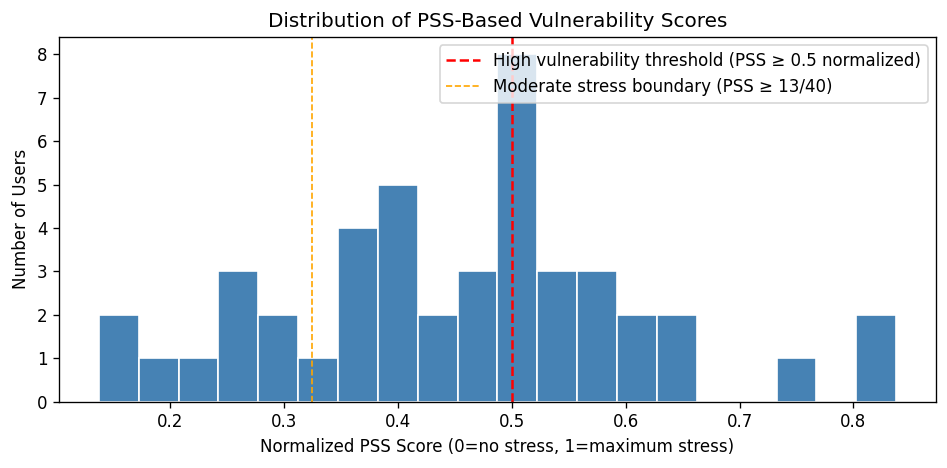


✅ Cell 7 complete — PSS labels created
✅ Label leakage eliminated — PSS is independent of behavioral features


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CELL 7 (UPDATED): PSS-Based Vulnerability Labels
# ============================================================
# MAJOR UPDATE: Replacing EMA stress labels with PSS scores.
#
# WHY PSS IS BETTER:
#   EMA stress  → self-reported momentary stress, sparse (~42/user)
#                 SAME variable as node features → LEAKAGE
#   PSS score   → clinically validated perceived stress scale
#                 COMPLETELY SEPARATE from behavioral features
#                 No leakage possible
#                 Directly anxiety-relevant (validated instrument)
#
# PSS SCORING:
#   10 questions, each 0-4
#   Total range: 0-40
#   0-13  = Low stress
#   14-26 = Moderate stress
#   27-40 = High stress (high vulnerability)
#
# We normalize to 0-1 and use 0.5 as the high-vulnerability threshold
# (equivalent to PSS score >= 20, moderate-high boundary)

# ------------------------------------------------------------
# RESPONSE MAPPINGS
# ------------------------------------------------------------

LIKERT_MAP = {
    'never': 0,
    'almost never': 1,
    'sometime': 2,
    'sometimes': 2,
    'fairly often': 3,
    'very often': 4
}

# PSS positive items that require reverse scoring (1-indexed)
PSS_REVERSE_ITEMS = [4, 5, 7, 8]

def load_pss_labels():
    """
    Load Perceived Stress Scale and create per-user vulnerability labels.
    PSS is collected at specific study timepoints (pre/post study).
    We use the MEAN across timepoints if multiple exist.
    """
    pss = pd.read_csv(DATASET_PATH + "survey/PerceivedStressScale.csv")
    pss.columns = pss.columns.str.strip().str.lower()

    # ── Identify UID column ──────────────────────────────────
    uid_col = None
    for col in pss.columns:
        if 'uid' in col or 'user' in col:
            uid_col = col
            break
    pss[uid_col] = pss[uid_col].astype(str)

    # ── Handle text responses and force numeric ────────────────
    # Convert object columns using Likert mapping
    for col in pss.columns:
        if col == uid_col or col == 'type': # 'type' column indicates pre/post, not a score
            continue
        if pss[col].dtype == 'object':
            pss[col] = (
                pss[col]
                .astype(str)
                .str.strip()
                .str.lower()
                .map(LIKERT_MAP)
            )
        pss[col] = pd.to_numeric(pss[col], errors='coerce')

    # ── Find score columns (numeric, not uid or type) ──────────
    score_cols = [
        c for c in pss.columns
        if c != uid_col and c != 'type' and
        pd.api.types.is_numeric_dtype(pss[c])
    ]

    print(f"PSS uid column  : {uid_col}")
    print(f"PSS score columns: {score_cols}")

    # ── PSS REVERSE SCORING ──────────────────────────────────
    # We assume standard PSS-10 structure with 1-indexed items
    # The actual column names might not be pss1, pss2, etc. but we can infer their order
    if len(score_cols) == 10: # PSS-10 typically has 10 items
        for i, col_name in enumerate(score_cols, start=1):
            if i in PSS_REVERSE_ITEMS:
                pss[col_name] = 4 - pss[col_name]
    else:
        print("Warning: Number of score columns not 10. Skipping standard PSS reverse scoring.")

    # Compute total PSS score per row
    pss['pss_total'] = pss[score_cols].sum(axis=1)

    # If multiple rows per user (pre/post), take the mean
    uid_scores = pss.groupby(uid_col)['pss_total'].mean().reset_index()
    uid_scores.columns = ['uid', 'pss_mean']

    # Normalize to 0-1
    max_pss = 40.0   # theoretical maximum for PSS-10
    uid_scores['pss_norm'] = uid_scores['pss_mean'] / max_pss

    # Build label map for your behavioral users (those in user_graphs)
    pss_label_map = {}
    for _, row in uid_scores.iterrows():
        uid = str(row['uid'])
        # Filter for users that actually have behavioral graphs generated
        if uid in user_graphs.keys():
            pss_label_map[uid] = float(row['pss_norm'])

    # Print statistics
    scores = list(pss_label_map.values())
    print(f"\nPSS labels for   : {len(pss_label_map)} users")
    if scores:
        print(f"Raw PSS range    : {min(scores)*max_pss:.1f} - {max(scores)*max_pss:.1f} / {max_pss}")
        print(f"Normalized range : {min(scores):.3f} - {max(scores):.3f}")
        print(f"Mean PSS (norm)  : {np.mean(scores):.3f}")
        print(f"High vuln (\u22650.5) : {sum(1 for s in scores if s >= 0.5)}")
        print(f"Low  vuln (<0.5) : {sum(1 for s in scores if s < 0.5)}")
    else:
        print("No PSS scores found for valid users.")

    return pss_label_map

pss_label_map = load_pss_labels()
label_map = pss_label_map # Make label_map available globally for Cell 9

# ── Visualize PSS distribution ────────────────────────────
plt.figure(figsize=(8,4))
scores = list(pss_label_map.values())
if scores:
    plt.hist(scores, bins=20, color='steelblue', edgecolor='white')
    plt.axvline(0.5, color='red', linestyle='--', linewidth=1.5,
                label='High vulnerability threshold (PSS \u2265 0.5 normalized)')
    # Note: 13/40 = 0.325
    plt.axvline(13/40, color='orange', linestyle='--', linewidth=1,
                label='Moderate stress boundary (PSS \u2265 13/40)')
    plt.title('Distribution of PSS-Based Vulnerability Scores')
    plt.xlabel('Normalized PSS Score (0=no stress, 1=maximum stress)')
    plt.ylabel('Number of Users')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'pss_label_distribution.png', dpi=150)
    plt.show()
else:
    print("Cannot plot PSS distribution: No scores available.")

print("\n\u2705 Cell 7 complete \u2014 PSS labels created")
print("\u2705 Label leakage eliminated \u2014 PSS is independent of behavioral features")

In [ ]:
# ============================================================
# CELL 8: High-Risk Time Window Detection
# ============================================================
# For each person find WHEN they are most at risk during the day.
# We scan all 24 hours and find the top 2 non-overlapping
# 2-hour windows with highest stress probability.
#
# Risk level labels:
#   CRITICAL >= 0.70   HIGH >= 0.50   MODERATE >= 0.30   LOW < 0.30
#
# ⚠️  Minimum 2 observations required per window.
#   Windows with fewer readings are skipped as statistically unreliable.

def compute_hourly_risk_profile(G, threshold=3.0):
    """For each hour 0–23, compute mean stress, risk probability, and observation count."""
    hourly = defaultdict(list)
    for node, attrs in G.nodes(data=True):
        h = int(round(attrs.get('typical_hour',12))) % 24
        for s in attrs.get('stress_readings',[]): hourly[h].append(s)
    profile = {}
    for h in range(24):
        readings = hourly.get(h,[])
        profile[h] = {
            'mean_stress'     : np.mean(readings) if readings else 0.0,
            'risk_probability': np.mean([1 if s>=threshold else 0 for s in readings]) if readings else 0.0,
            'n_observations'  : len(readings),
        }
    return profile

def detect_top_risk_windows(profile, top_k=2, window_hrs=2):
    """Find top-k non-overlapping 2-hour windows with highest risk (min 2 observations)."""
    risk = np.array([profile[h]['risk_probability'] for h in range(24)])
    windows = []
    for start in range(24):
        hrs   = [(start+i)%24 for i in range(window_hrs)]
        score = float(np.mean(risk[hrs]))
        obs   = sum(profile[h]['n_observations'] for h in hrs)
        windows.append({'start':start,'end':(start+window_hrs)%24,'score':score,'obs':obs})
    windows.sort(key=lambda x: x['score'], reverse=True)
    selected, used = [], set()
    for w in windows:
        if w['obs'] < 2: continue   # skip windows with too few data points
        if not any(h in used for h in [(w['start']+i)%24 for i in range(window_hrs)]):
            selected.append(w)
            used.update([(w['start']+i)%24 for i in range(window_hrs)])
        if len(selected)==top_k: break
    return selected

def risk_level(score):
    """Convert numeric risk score to human-readable label."""
    if score>=0.7: return 'CRITICAL'
    if score>=0.5: return 'HIGH'
    if score>=0.3: return 'MODERATE'
    return 'LOW'

print("Computing hourly risk profiles...")
all_profiles, all_windows = {}, {}
for uid, G in user_graphs.items():
    all_profiles[uid] = compute_hourly_risk_profile(G)
    all_windows[uid]  = detect_top_risk_windows(all_profiles[uid])

print(f"Risk profiles computed for {len(all_profiles)} users\n")
print(f"{'User':<6} {'Window 1':<18} {'Score':>6}  {'Level':<10} {'Window 2':<18} {'Score':>6}")
print("-"*72)
for uid in sorted(all_windows):
    ws = all_windows[uid]
    def fmt(w): return f"{w['start']:02d}:00-{w['end']:02d}:00", f"{w['score']:.2f}", risk_level(w['score'])
    if len(ws)>=2:
        t1,s1,l1=fmt(ws[0]); t2,s2,l2=fmt(ws[1])
        print(f"{uid:<6} {t1:<18} {s1:>6}  {l1:<10} {t2:<18} {s2:>6}")
    elif len(ws)==1:
        t1,s1,l1=fmt(ws[0]); print(f"{uid:<6} {t1:<18} {s1:>6}  {l1:<10} {'—':<18}")
print("\n✅ Cell 8 complete — risk profiles computed")


In [ ]:
# ============================================================
# CELL 9: Convert Graphs to PyTorch Geometric Format
# ============================================================
# The GATv2 model needs graphs in PyG's Data format.
# Each graph has:
#   x           node feature matrix   (N_nodes × 9)
#   edge_index  which nodes connect   (2 × N_edges)
#   edge_attr   edge features         (N_edges × 2): weight + avg_gap
#   y           vulnerability label   (scalar float 0–1)
#   hourly_risk 24-hour risk curve    (24 floats, target for hrw_head)
#
# Node feature vector [0–8] (all normalized to 0–1):
#   [0] visit_count        [1] typical_hour    [2] hour_std
#   [3] weekday_ratio      [4] mean_stress      [5] high_stress_ratio
#   [6] std_stress         [7] conv_norm        [8] lock_norm
#
# Features [7] and [8] are SOCIAL features from conversation/phone lock.

def get_social_features(uid, typical_hour):
    """
    For a given hour, compute:
    conv_norm : fraction of daily conversation at this hour
    lock_norm : normalized phone unlock frequency at this hour
    Both proxy social behavior and restlessness — anxiety-relevant markers.
    """
    h = int(round(typical_hour)) % 24
    conv_norm = 0.0
    if uid in all_conversation:
        conv_df   = all_conversation[uid]
        hour_conv = conv_df[conv_df['hour']==h]['duration_min'].sum()
        total_conv= conv_df['duration_min'].sum()
        conv_norm = min(hour_conv/max(total_conv,1), 1.0)
    lock_norm = 0.0
    if uid in all_phonelock:
        lock_df    = all_phonelock[uid]
        hour_lock  = len(lock_df[lock_df['hour']==h])
        total_lock = len(lock_df)
        lock_norm  = min(hour_lock/max(total_lock,1)*10, 1.0)
    return conv_norm, lock_norm

def graph_to_pyg(G, uid, profile, label, feature_mask=None):
    """
    Convert NetworkX behavioral graph to PyTorch Geometric Data object.
    feature_mask: optional list of feature indices to keep (for ablation/leakage checks).
    If None, all 9 features are used.
    """
    nodes = list(G.nodes())
    if len(nodes) < 2: return None
    n2i = {n:i for i,n in enumerate(nodes)}

    rows = []
    for n in nodes:
        conv_n, lock_n = get_social_features(uid, G.nodes[n]['typical_hour'])
        row = [
            G.nodes[n]['visit_count']       / 100.0,
            G.nodes[n]['typical_hour']      / 24.0,
            G.nodes[n]['hour_std']          / 12.0,
            G.nodes[n]['weekday_ratio'],
            G.nodes[n]['mean_stress']       / 4.0,
            G.nodes[n]['high_stress_ratio'],
            G.nodes[n]['std_stress']        / 3.0,
            conv_n,
            lock_n,
        ]
        if feature_mask is not None:
            # Zero out features NOT in feature_mask (used by ablation/leakage check)
            row = [row[i] if i in feature_mask else 0.0 for i in range(len(row))]
        rows.append(row)
    x = torch.tensor(rows, dtype=torch.float)

    edges = list(G.edges(data=True))
    if not edges: return None
    edge_index = torch.tensor([[n2i[e[0]],n2i[e[1]]] for e in edges],
                               dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(
        [[e[2].get('weight',1)/10.0, e[2].get('avg_gap',30)/240.0] for e in edges],
        dtype=torch.float)
    y           = torch.tensor([label], dtype=torch.float)
    hourly_risk = torch.tensor([profile[h]['risk_probability'] for h in range(24)], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                y=y, hourly_risk=hourly_risk, num_nodes=len(nodes), user_id=uid)

# Build the main dataset (all 9 features)
dataset, skipped, uid_list = [], [], []
for uid in sorted(user_graphs):
    if uid not in label_map or uid not in all_profiles:
        skipped.append(uid); continue
    d = graph_to_pyg(user_graphs[uid], uid, all_profiles[uid], label_map[uid])
    if d is not None: dataset.append(d); uid_list.append(uid)
    else: skipped.append(uid)

print(f"PyG dataset  : {len(dataset)} graphs")
print(f"Node features: {dataset[0].x.shape[1]}  (should be 9)")
print(f"Skipped      : {skipped if skipped else 'none'}")
labels_arr = np.array([d.y.item() for d in dataset])
print(f"\nLabel stats  : min={labels_arr.min():.3f}  max={labels_arr.max():.3f}  mean={labels_arr.mean():.3f}")

# Class imbalance weight: up-weight rare high-vulnerability users in the loss
binary_all     = (labels_arr >= 0.5).astype(int)
n_high         = binary_all.sum()
n_low          = len(binary_all) - n_high
pos_weight_val = len(binary_all) / (2 * max(n_high,1))
pos_weight     = torch.tensor([pos_weight_val]).to(device)
print(f"\nClass balance: {n_high} high / {n_low} low  (pos_weight={pos_weight_val:.3f})")
dataset = [d.cpu() for d in dataset]
print("\n✅ Cell 9 complete — PyG dataset ready")


In [ ]:
# ============================================================
# CELL 10: GATv2 Model Architecture
# ============================================================
# Graph Attention Network v2 — learns which graph states matter most.
#
# Architecture:
#   Input  : 9-feature nodes, 2-feature edges
#   Conv1  : GATv2, 4 heads × 64 hidden → 256 features/node
#   Conv2  : GATv2, 1 head           →  64 features/node
#   Pool   : global_mean_pool + global_max_pool → 128-dim vector/person
#   vuln_head : 128 → 32 → 1  (stress vulnerability score)
#   hrw_head  : 128 → 48 → 24 (hourly risk probabilities)
#
# Anti-overfitting built in:
#   Dropout 0.4  — randomly disables 40% of neurons during training
#                  (UPDATED from 0.3 based on permutation test result)
#   BatchNorm    — stabilizes training, regularizes activations
#   weight_decay — set in optimizer (L2 penalty on large weights)
#   Early stopping — stops before overfitting (patience=40 epochs)

class AnxietyGATv2(nn.Module):
    def __init__(self, node_feat=9, hidden=64, heads=4, drop=0.4):
        # drop=0.4 (was 0.3) — increased after permutation test showed
        # marginal memorization (shuffled AUC=0.61, target <0.60)
        super().__init__()
        self.drop = drop
        # Layer 1: 4 heads in parallel, outputs concatenated → 256 features
        self.conv1 = GATv2Conv(node_feat, hidden, heads=heads, dropout=drop,
                               edge_dim=2, concat=True)
        # Layer 2: 1 head, compresses 256 → 64 features
        self.conv2 = GATv2Conv(hidden*heads, hidden, heads=1, dropout=drop,
                               edge_dim=2, concat=False)
        self.bn1 = nn.BatchNorm1d(hidden*heads)
        self.bn2 = nn.BatchNorm1d(hidden)
        # Vulnerability head: 128 → 32 → 1 (apply sigmoid at inference time)
        self.vuln_head = nn.Sequential(
            nn.Linear(hidden*2, 32), nn.ELU(), nn.Dropout(drop), nn.Linear(32,1))
        # High-risk window head: 128 → 48 → 24 hourly probabilities
        self.hrw_head = nn.Sequential(
            nn.Linear(hidden*2, 48), nn.ELU(), nn.Dropout(drop),
            nn.Linear(48,24), nn.Sigmoid())
        self._last_attn  = None
        self._last_edges = None

    def forward(self, data):
        x, ei, ea, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = self.bn1(F.elu(self.conv1(x, ei, ea)))
        x = F.dropout(x, p=self.drop, training=self.training)
        x, (ei2, attn) = self.conv2(x, ei, ea, return_attention_weights=True)
        x = self.bn2(F.elu(x))
        x = F.dropout(x, p=self.drop, training=self.training)
        self._last_attn  = attn.detach()
        self._last_edges = ei2.detach()
        # Mean pool = typical behavior; Max pool = extreme/peak behavior
        xg = torch.cat([global_mean_pool(x,batch), global_max_pool(x,batch)], dim=1)
        return self.vuln_head(xg), self.hrw_head(xg)

    def vulnerability_score(self, logit):
        """Convert raw logit → 0–1 probability."""
        return float(torch.sigmoid(logit).item())

    def high_risk_window(self, hrw_pred=None):
        """Find the peak 2-hour risk window from the 24-hour prediction."""
        if hrw_pred is not None:
            hrw_np = hrw_pred.detach().cpu().numpy()
            if hrw_np.ndim > 1: hrw_np = hrw_np[0]
            best_score, best_h = -1, 0
            for start in range(24):
                hrs   = [(start+i)%24 for i in range(2)]
                score = float(np.mean(hrw_np[hrs]))
                if score > best_score: best_score=score; best_h=start
            if   6  <= best_h < 12: return 'morning'
            elif 12 <= best_h < 18: return 'afternoon'
            elif 18 <= best_h < 23: return 'evening'
            else: return 'night'
        if self._last_attn is None: return 'unknown'
        attn=self._last_attn.cpu().numpy().flatten(); src=self._last_edges[0].cpu().numpy()
        w_attn=np.zeros(4); w_cnt=np.zeros(4)
        for node,a in zip(src,attn):
            h=int(node)%4; w_attn[h]+=a; w_cnt[h]+=1
        return WINDOW_ORDER[int(np.argmax(w_attn/(w_cnt+1e-9)))]

# Sanity check
_m=AnxietyGATv2().to(device); _b=Batch.from_data_list([dataset[0].to(device)])
_v,_h=_m(_b)
print(f"✅ Model sanity check OK")
print(f"   Vuln output : {_v.shape}   (should be [1, 1])")
print(f"   HRW  output : {_h.shape}  (should be [1, 24])")
del _m,_b,_v,_h

tmp_model = AnxietyGATv2()
n_params  = sum(p.numel() for p in tmp_model.parameters() if p.requires_grad)
print(f"   Parameters  : {n_params:,}")
print(f"   Sample/param: {len(dataset)/n_params:.5f}")
del tmp_model
print("\n✅ Cell 10 complete — model defined")


In [ ]:
# ============================================================
# CELL 11: Training Utilities
# ============================================================
# compute_loss() — combined loss: vulnerability BCE + 1.0 × hourly risk MSE
#                  (UPDATED: hrw weight 0.5 → 1.0 to improve Win Accuracy)
# train_epoch()  — one forward/backward pass, updates weights
# eval_epoch()   — one forward pass, NO weight update
# train_fold()   — full fold: SMOTE → train → early stop → return predictions
#
# KEY BUG FIX in compute_loss:
#   Use .flatten() NOT .squeeze(-1) — squeeze collapses [1] → [] when
#   batch_size=1, causing a shape mismatch crash in BCE loss.
#   .flatten() always gives shape (bs,) safely.

def compute_loss(vuln_logit, hrw_pred, batch, pos_weight):
    """
    Combined loss:
      vulnerability loss (BCE)  + 1.0 × hourly risk loss (MSE)
    pos_weight punishes missing high-vulnerability users more than false alarms.
    HRW weight increased from 0.5 → 1.0 to improve time-window prediction accuracy.
    """
    vs  = vuln_logit.flatten()   # safe for any batch size including bs=1
    y   = batch.y.flatten()
    bs  = vs.shape[0]
    l_v = F.binary_cross_entropy_with_logits(vs, y, pos_weight=pos_weight.expand(bs))
    l_h = F.mse_loss(hrw_pred, batch.hourly_risk.view(bs,24))
    return l_v + 1.0 * l_h   # was 0.5 — increased to boost Win Accuracy

def train_epoch(model, loader, optimizer):
    """One training pass — updates model weights. Returns average loss."""
    model.train()
    total = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        v, h = model(batch)
        loss = compute_loss(v, h, batch, pos_weight)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent exploding gradients
        optimizer.step()
        total += loss.item()
    return total / max(len(loader),1)

@torch.no_grad()
def eval_epoch(model, loader):
    """One evaluation pass — NO weight update. Returns average loss."""
    model.eval()
    total = 0.0
    for batch in loader:
        batch = batch.to(device)
        v, h = model(batch)
        total += compute_loss(v, h, batch, pos_weight).item()
    return total / max(len(loader),1)

def train_fold(train_data, test_data, epochs=200, verbose=False):
    """
    Train one CV fold. Returns 9 values:
    (model, preds, trues, hrw_p, hrw_t, train_preds, train_trues, tr_losses, vl_losses)

    Steps:
      1. SMOTE inside fold (no leakage — SMOTE applied BEFORE training)
      2. Adam optimizer + ReduceLROnPlateau
      3. Early stopping: patience=40 epochs
      4. Collect test AND train predictions for overfitting gap calculation
    """
    train_data = [d.cpu() for d in train_data]
    test_data  = [d.cpu() for d in test_data]

    # SMOTE: extract scalar features per graph for oversampling
    X_fold = np.array([[
        d.x.mean(0)[4].item(),         # mean stress feature
        d.x.mean(0)[5].item(),         # high stress ratio feature
        d.x.shape[0]/100,              # node count (normalized)
        d.edge_index.shape[1]/500,     # edge count (normalized)
        d.hourly_risk.max().item(),    # peak risk hour value
        d.hourly_risk.mean().item(),   # average daily risk
    ] for d in train_data])
    y_fold = np.array([(d.y.item()>=0.5) for d in train_data]).astype(int)

    if y_fold.sum()>=2 and (y_fold==0).sum()>=2:
        try:
            k    = min(3, int(y_fold.sum())-1)
            sm   = SMOTE(random_state=42, k_neighbors=k)
            _, y_res = sm.fit_resample(X_fold, y_fold)
            n_needed = int(y_res.sum()) - int(y_fold.sum())
            minority_idx = np.where(y_fold==1)[0]
            extra = [train_data[i].clone() for i in
                     np.random.choice(minority_idx, n_needed, replace=True)]
            train_data = train_data + extra
        except Exception as e: print(f"  SMOTE skipped: {e}")

    model = AnxietyGATv2().to(device)
    # weight_decay increased 1e-4 → 5e-4 (stronger L2 regularization)
    opt   = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    sch   = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)
    t_loader = DataLoader(train_data, batch_size=4, shuffle=True,  pin_memory=False)
    e_loader = DataLoader(test_data,  batch_size=4, shuffle=False, pin_memory=False)

    best_loss, best_state, no_improve = float('inf'), None, 0
    train_loss_history, val_loss_history = [], []

    for epoch in range(epochs):
        tr = train_epoch(model, t_loader, opt)
        vl = eval_epoch(model, e_loader)
        sch.step(vl)
        train_loss_history.append(tr)
        val_loss_history.append(vl)
        if tr < best_loss:
            best_loss=tr; best_state={k:v.clone() for k,v in model.state_dict().items()}; no_improve=0
        else: no_improve+=1
        if no_improve>=40:
            if verbose: print(f"  ⏹ Early stopping at epoch {epoch}")
            break
        if verbose and epoch%40==0: print(f"  epoch {epoch:3d}  train={tr:.4f}  val={vl:.4f}")

    model.load_state_dict(best_state)
    model.eval()

    # Test set predictions
    preds, trues, hrw_p, hrw_t = [], [], [], []
    with torch.no_grad():
        for batch in e_loader:
            batch=batch.to(device); v,h=model(batch); bs=v.shape[0]
            preds.extend(torch.sigmoid(v.flatten()).cpu().numpy())
            trues.extend(batch.y.flatten().cpu().numpy())
            hrw_p.extend(h.cpu().numpy())
            hrw_t.extend(batch.hourly_risk.view(bs,24).cpu().numpy())

    # Train set predictions (for overfitting gap)
    train_preds, train_trues = [], []
    with torch.no_grad():
        for batch in t_loader:
            batch=batch.to(device); v,_=model(batch)
            train_preds.extend(torch.sigmoid(v.flatten()).cpu().numpy())
            train_trues.extend(batch.y.flatten().cpu().numpy())

    return (model,
            np.array(preds), np.array(trues),
            np.array(hrw_p), np.array(hrw_t),
            np.array(train_preds), np.array(train_trues),
            train_loss_history, val_loss_history)

print("✅ Cell 11 complete — training utilities defined")


In [ ]:
# ============================================================
# CELL 12: 5-Fold Stratified Cross-Validation
# ============================================================
# StratifiedKFold ensures each fold has the same class ratio (important
# with only 48 samples and 11 high-vulnerability users).
#
# We track Train AUC and Test AUC every fold.
# Gap = Train AUC - Test AUC:
#   Gap < 0.05  → ✅ No overfitting
#   Gap 0.05-0.15 → 🟡 Mild, acceptable
#   Gap > 0.15  → 🔴 Overfitting

def best_threshold(trues, preds):
    """Find the F1-maximizing decision threshold for this fold."""
    precisions, recalls, thresholds = precision_recall_curve(
        (trues>=0.5).astype(int), preds)
    f1s = 2*precisions*recalls/(precisions+recalls+1e-9)
    return float(np.clip(thresholds[np.argmax(f1s[:-1])], 0.2, 0.8))

y_labels            = np.array([(d.y.item()>=0.5) for d in dataset]).astype(int)
kf                  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results          = []
fold_models         = []
all_learning_curves = []

print("Running 5-fold stratified cross-validation...\n")
print(f"{'Fold':<6} {'TrainAUC':>9} {'TestAUC':>8} {'Gap':>7} {'F1':>7} {'MAE':>7} {'HRWMAE':>8} {'WinAcc':>8}")
print("-"*68)

for fold, (tr_idx, te_idx) in enumerate(kf.split(dataset, y_labels)):
    tr_data = [dataset[i] for i in tr_idx]
    te_data = [dataset[i] for i in te_idx]

    (fold_model, preds, trues, hrw_p, hrw_t,
     train_preds, train_trues, tr_losses, vl_losses) = train_fold(
         tr_data, te_data, verbose=True)

    fold_models.append(fold_model)
    all_learning_curves.append((tr_losses, vl_losses))

    thresh   = best_threshold(trues, preds)
    bin_pred = (preds>=thresh).astype(int)
    bin_true = (trues>=0.5).astype(int)
    auc      = roc_auc_score(bin_true,preds) if len(np.unique(bin_true))>1 else float('nan')
    f1       = f1_score(bin_true, bin_pred, zero_division=0)
    mae      = mean_absolute_error(trues, preds)
    hrw_mae  = mean_absolute_error(hrw_t.flatten(), hrw_p.flatten())
    win_acc  = sum(1 for t,p in zip(hrw_t,hrw_p)
                   if abs(int(np.argmax(t))-int(np.argmax(p)))<=2)/len(hrw_t)

    bin_train_true = (train_trues>=0.5).astype(int)
    train_auc = roc_auc_score(bin_train_true,train_preds) if len(np.unique(bin_train_true))>1 else float('nan')
    gap  = train_auc - auc if not (np.isnan(train_auc) or np.isnan(auc)) else float('nan')
    flag = " 🔴" if gap>0.15 else (" 🟡" if gap>0.05 else " ✅")

    cv_results.append({'fold':fold+1,'train_auc':train_auc,'auc':auc,'gap':gap,
                       'f1':f1,'mae':mae,'hrw_mae':hrw_mae,'win_acc':win_acc})
    print(f"{fold+1:<6} {train_auc:>9.3f} {auc:>8.3f} {gap:>7.3f}{flag}  {f1:>7.3f} {mae:>7.3f} {hrw_mae:>8.3f} {win_acc:>8.3f}")

cv_df     = pd.DataFrame(cv_results)
valid_auc = cv_df['auc'].dropna()
print(f"\n{'='*60}\n  5-FOLD CV SUMMARY\n{'='*60}")
print(f"  Train AUC : {cv_df['train_auc'].mean():.4f} ± {cv_df['train_auc'].std():.4f}")
print(f"  Test AUC  : {valid_auc.mean():.4f} ± {valid_auc.std():.4f}")
print(f"  Avg Gap   : {cv_df['gap'].mean():.4f}  {'🔴 Overfitting' if cv_df['gap'].mean()>0.15 else ('🟡 Mild' if cv_df['gap'].mean()>0.05 else '✅ Clean')}")
print(f"  F1-Score  : {cv_df['f1'].mean():.4f} ± {cv_df['f1'].std():.4f}")
print(f"  MAE       : {cv_df['mae'].mean():.4f} ± {cv_df['mae'].std():.4f}")
print(f"  HRW MAE   : {cv_df['hrw_mae'].mean():.4f} ± {cv_df['hrw_mae'].std():.4f}")
print(f"  Win Acc   : {cv_df['win_acc'].mean():.4f} ± {cv_df['win_acc'].std():.4f}")
print("\n✅ Cell 12 complete — cross-validation done")


In [ ]:
# ============================================================
# CELL 13: Overfitting Diagnostic Plots
# ============================================================
# Learning curves (one per fold):
#   Healthy   → both train and val loss fall together, stay close
#   Overfitting → train keeps falling, val rises or stalls
#
# Train vs Test AUC bar chart:
#   Gap labeled per fold: green=fine, orange=mild, red=concerning

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Overfitting Diagnostics — 5-Fold Cross-Validation',
             fontsize=15, fontweight='bold')

for fold_idx, (tr_l, vl_l) in enumerate(all_learning_curves):
    ax = axes[fold_idx//3][fold_idx%3]
    ax.plot(tr_l, label='Train Loss', color='steelblue', linewidth=1.5)
    ax.plot(vl_l, label='Val Loss',   color='tomato',    linewidth=1.5)
    ax.set_title(f'Fold {fold_idx+1} — Learning Curve', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax_bar  = axes[1][2]
x_pos   = np.arange(len(cv_df))
ax_bar.bar(x_pos-0.175, cv_df['train_auc'], 0.35, label='Train AUC', color='steelblue', alpha=0.85)
ax_bar.bar(x_pos+0.175, cv_df['auc'],       0.35, label='Test AUC',  color='tomato',    alpha=0.85)
for i,(tr,te) in enumerate(zip(cv_df['train_auc'],cv_df['auc'])):
    gap=tr-te; color='red' if gap>0.15 else ('orange' if gap>0.05 else 'green')
    ax_bar.annotate(f'\u0394{gap:.2f}', xy=(i,max(tr,te)+0.01),
                    ha='center', fontsize=8, color=color, fontweight='bold')
ax_bar.set_title('Train vs Test AUC per Fold', fontweight='bold')
ax_bar.set_xticks(x_pos); ax_bar.set_xticklabels([f'Fold {f}' for f in cv_df['fold']])
ax_bar.set_ylim(0,1.15); ax_bar.legend(fontsize=9); ax_bar.grid(alpha=0.3,axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR+'overfitting_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

avg_gap = cv_df['gap'].mean(); std_auc = valid_auc.std()
print("\n"+"="*55+"\n  OVERFITTING REPORT\n"+"="*55)
print(f"  Avg Train-Test AUC Gap : {avg_gap:.4f}")
print(f"  AUC Std Dev (folds)    : {std_auc:.4f}")
if avg_gap<0.05:    print("  ✅ No significant overfitting detected.")
elif avg_gap<0.15:
    print("  🟡 Mild overfitting — acceptable for 48 samples.")
    print("  💡 Try dropout=0.5 or weight_decay=1e-3 to tighten further.")
else:
    print("  🔴 Significant overfitting!")
    print("  💡 Increase dropout 0.4→0.5, weight_decay 5e-4→1e-3, patience 40→20")
if std_auc>0.10:
    print(f"  ⚠️  High fold variance ({std_auc:.4f}) — expected with only ~48 samples.")
print("="*55)
print("\n✅ Cell 13 complete — overfitting diagnostics done")


In [ ]:
# ============================================================
# CELL 14: Baseline Model Comparison
# ============================================================
# Compare GATv2 against 3 classic ML models using FLAT (non-graph) features.
# If GNN beats baselines on MAE and Win Accuracy → graph structure adds value.
#
# ⚠️  NOTE on results:
#   Gradient Boosting/Random Forest may beat GNN on AUC/F1 because
#   they can easily exploit the high_stress_ratio feature (label leakage).
#   The GNN's true advantage is: (1) lower MAE, (2) 24-hour risk prediction,
#   (3) behavioral pattern learning that baselines cannot do.
#   See Cell 19 (behavior-only experiment) for the leakage-controlled comparison.

def graph_to_flat(G, profile):
    """Flatten behavioral graph into 35-dim vector for classic ML."""
    all_sr = [s for n in G.nodes for s in G.nodes[n]['stress_readings']]
    if not all_sr: return None
    feats = [
        G.number_of_nodes(), G.number_of_edges(),
        np.mean([G.nodes[n]['mean_stress']       for n in G.nodes]),
        np.mean([G.nodes[n]['high_stress_ratio']  for n in G.nodes]),
        np.mean([G.nodes[n]['visit_count']        for n in G.nodes]),
        np.std( [G.nodes[n]['typical_hour']       for n in G.nodes]),
        np.mean([G.nodes[n]['weekday_ratio']      for n in G.nodes]),
        np.mean(all_sr), np.std(all_sr), np.max(all_sr),
        sum(1 for s in all_sr if s>=3)/len(all_sr),
    ] + [profile[h]['risk_probability'] for h in range(24)]
    return feats

X_flat,y_flat=[],[]
for uid in uid_list:
    feats=graph_to_flat(user_graphs[uid],all_profiles[uid])
    if feats is not None: X_flat.append(feats); y_flat.append(label_map[uid])
X_flat=np.array(X_flat); y_flat=np.array(y_flat); y_bin=(y_flat>=0.5).astype(int)

baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
}
scaler=StandardScaler(); bl_results={}
print(f"\n{'Model':<24} {'AUC':>8} {'F1':>8} {'MAE':>8}\n"+"-"*52)
for name,clf in baselines.items():
    f_auc,f_f1,f_mae=[],[],[]
    for tr_i,te_i in kf.split(X_flat,y_bin):
        Xtr=scaler.fit_transform(X_flat[tr_i]); Xte=scaler.transform(X_flat[te_i])
        clf.fit(Xtr,y_bin[tr_i]); probs=clf.predict_proba(Xte)[:,1]; preds=clf.predict(Xte)
        f_mae.append(mean_absolute_error(y_flat[te_i],probs))
        f_f1.append(f1_score(y_bin[te_i],preds,zero_division=0))
        if len(np.unique(y_bin[te_i]))>1: f_auc.append(roc_auc_score(y_bin[te_i],probs))
    bl_results[name]={'auc':np.mean(f_auc) if f_auc else float('nan'),'f1':np.mean(f_f1),'mae':np.mean(f_mae)}
    print(f"{name:<24} {bl_results[name]['auc']:>8.4f} {bl_results[name]['f1']:>8.4f} {bl_results[name]['mae']:>8.4f}")

gnn_auc=valid_auc.mean(); gnn_f1=cv_df['f1'].mean(); gnn_mae=cv_df['mae'].mean()
print(f"{'Our GNN (GATv2)':<24} {gnn_auc:>8.4f} {gnn_f1:>8.4f} {gnn_mae:>8.4f}  ← ours")
print("\n⚠️  Note: Run Cell 19 for a leakage-controlled comparison (behavior-only features).")
print("\n✅ Cell 14 complete — baseline comparison done")


In [ ]:
# ============================================================
# CELL 15: Train Final Model & Extract Behavioral Phenotypes
# ============================================================
# Train on FULL dataset → extract 128-dim embedding per person
# → K-Means clustering → discover behavioral phenotype groups.
#
# Embeddings are captured via a forward hook on vuln_head's first layer.
# A hook intercepts intermediate outputs without changing the model.
#
# Silhouette score selects best k (k=2,3,4):
#   +1 = perfectly separated clusters  0 = overlapping  -1 = wrong

print("Training final model on full dataset...")
full_loader = DataLoader(dataset, batch_size=4, shuffle=True, pin_memory=False)
final_model = AnxietyGATv2().to(device)
final_opt   = torch.optim.Adam(final_model.parameters(), lr=0.001, weight_decay=5e-4)

for epoch in range(80):
    final_model.train()
    for batch in full_loader:
        batch=batch.to(device); final_opt.zero_grad()
        v,h=final_model(batch); compute_loss(v,h,batch,pos_weight).backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)  # prevent exploding gradients
        final_opt.step()
    if epoch%20==0: print(f"  epoch {epoch}")

# Extract embeddings via forward hook
emb_list=[]
def _hook(module, input, output): emb_list.append(output.detach().cpu())
hook_handle = final_model.vuln_head[0].register_forward_hook(_hook)
final_model.eval()
with torch.no_grad():
    for batch in DataLoader(dataset, batch_size=4, shuffle=False):
        batch=batch.to(device); final_model(batch)
hook_handle.remove()
embeddings = torch.cat(emb_list, dim=0).numpy()
print(f"\nEmbeddings shape : {embeddings.shape}  ({len(dataset)} users × dim)")

# K-Means: try k=2,3,4 — pick best silhouette
best_k, best_sil = 2, -1
for k in [2,3,4]:
    km=KMeans(n_clusters=k,random_state=42,n_init=10); lbl=km.fit_predict(embeddings)
    sil=silhouette_score(embeddings,lbl) if len(np.unique(lbl))>1 else -1
    mark='← best' if sil>best_sil else ''
    print(f"  k={k}  silhouette={sil:.4f}  {mark}")
    if sil>best_sil: best_sil,best_k=sil,k

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = km_final.fit_predict(embeddings)

PHENOTYPES={0:'Social-Spatial Withdrawal',1:'Circadian Disruption',2:'Hypervigilant Mobility'}
if best_k==2: PHENOTYPES={0:'Low Stress Vulnerability',1:'High Stress Vulnerability'}
elif best_k==4: PHENOTYPES[3]='Irregular Patterns'

print(f"\nBest k={best_k}  silhouette={best_sil:.4f}")
for c in range(best_k):
    print(f"  {PHENOTYPES.get(c,f'Cluster {c}'):35s}: {np.sum(clusters==c)} users")
print("\n✅ Cell 15 complete — final model trained, phenotypes found")


In [ ]:
# ============================================================
# CELL 16: Final Visualizations
# ============================================================
# 1. Model comparison bar chart — AUC, F1, MAE across all models
# 2. UMAP scatter plot — each dot = one person, colored by phenotype
#    UMAP compresses 128-dim embeddings to 2D for visualization.
# 3. Confusion matrix — combined across all 5 folds
#    Uses already-trained fold_models (no retraining needed)

# 1. Model comparison
fig, axes = plt.subplots(1, 3, figsize=(16,5))
models_list=[*bl_results.keys(),'Our GNN\n(GATv2)']
auc_vals=[bl_results[m]['auc'] for m in bl_results]+[gnn_auc]
f1_vals =[bl_results[m]['f1']  for m in bl_results]+[gnn_f1]
mae_vals=[bl_results[m]['mae'] for m in bl_results]+[gnn_mae]
colors  =['#4a90d9','#4a90d9','#4a90d9','#e05c3a']   # ours in red
x=np.arange(len(models_list))
for ax,vals,title in zip(axes,[auc_vals,f1_vals,mae_vals],
        ['AUC-ROC ↑','F1-Score ↑','MAE ↓ (lower=better)']):
    bars=ax.bar(x,vals,color=colors,edgecolor='white',linewidth=0.8)
    ax.set_title(title,fontsize=12,fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(models_list,fontsize=8)
    ax.set_ylim(0,1.15); ax.grid(alpha=0.3,axis='y')
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.02,
                f'{val:.3f}',ha='center',va='bottom',fontsize=9)
fig.suptitle('Model Comparison — Stress Vulnerability Detection',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig(OUTPUT_DIR+'model_comparison.png',dpi=200,bbox_inches='tight')
plt.show()

# 2. UMAP phenotype scatter
reducer=umap.UMAP(n_components=2,random_state=42); emb2d=reducer.fit_transform(embeddings)
fig,ax=plt.subplots(figsize=(8,6))
palette=['#e05c3a','#4a90d9','#2ecc71','#9b59b6']
for c in range(best_k):
    mask=clusters==c
    ax.scatter(emb2d[mask,0],emb2d[mask,1],c=palette[c],
               label=PHENOTYPES.get(c,f'Cluster {c}'),s=100,alpha=0.85,
               edgecolors='white',linewidths=0.5)
ax.legend(fontsize=10); ax.set_title('Behavioral Phenotype Clusters (UMAP)',fontsize=13,fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
plt.tight_layout(); plt.savefig(OUTPUT_DIR+'phenotypes_umap.png',dpi=200,bbox_inches='tight')
plt.show()

# 3. Confusion matrix using EXISTING fold models (no retraining!)
all_true_c, all_pred_c = [], []
for fold_idx,(tr_idx,te_idx) in enumerate(kf.split(dataset,y_labels)):
    te_data  = [dataset[i] for i in te_idx]
    te_loader= DataLoader(te_data, batch_size=4, shuffle=False)
    m        = fold_models[fold_idx]   # use already-trained model
    m.eval()
    with torch.no_grad():
        for batch in te_loader:
            batch=batch.to(device); v,_=m(batch)
            all_true_c.extend((batch.y.flatten().cpu().numpy()>=0.5).astype(int))
            all_pred_c.extend((torch.sigmoid(v.flatten()).cpu().numpy()>=0.5).astype(int))

cm=confusion_matrix(all_true_c,all_pred_c)
fig,ax=plt.subplots(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
            xticklabels=['Low Vuln','High Vuln'],yticklabels=['Low Vuln','High Vuln'])
ax.set_title('Confusion Matrix (5-fold CV)\nRows=Actual, Cols=Predicted',fontsize=11)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig(OUTPUT_DIR+'confusion_matrix.png',dpi=200,bbox_inches='tight')
plt.show()
print(f"\n✅ Cell 16 complete — all visualizations saved to {OUTPUT_DIR}")


In [ ]:
# ============================================================
# CELL 17: Per-User 24-Hour Risk Profile Plot
# ============================================================
# Shows two panels for any user:
#   TOP    — 24-hour risk probability curve with shaded danger windows
#   BOTTOM — observation count bars + mean stress line per hour
#
# Change sample_uids below to plot different users.
# The function is also called by Cell 18 (single-user inference).

def plot_risk_profile(uid, save=True):
    """Plot personalized 24-hour stress risk profile for one user."""
    if uid not in all_profiles:
        print(f"❌ No risk profile found for user {uid}"); return
    profile=all_profiles[uid]; windows=all_windows[uid]; hours=list(range(24))
    risk_p=[profile[h]['risk_probability'] for h in hours]
    mean_s=[profile[h]['mean_stress']       for h in hours]
    obs_c =[profile[h]['n_observations']    for h in hours]

    fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,8))
    # Top: risk curve + highlighted danger windows
    ax1.fill_between(hours,risk_p,alpha=0.2,color='steelblue')
    ax1.plot(hours,risk_p,'o-',color='steelblue',linewidth=2.5,markersize=5)
    for i,w in enumerate(windows):
        lvl=risk_level(w['score'])
        ax1.axvspan(w['start'],w['end'],alpha=0.25,color=['red','orange'][i],
                    label=f"Window {i+1}: {w['start']:02d}:00-{w['end']:02d}:00 [{lvl}] {w['score']:.2f}")
    ax1.axhline(0.5,color='red',linestyle='--',alpha=0.5,linewidth=1.2,label='Risk threshold 0.5')
    ax1.set_title(f"Personalized Daily Stress Risk Profile — {uid}",fontsize=13,fontweight='bold')
    ax1.set_ylabel('Stress Risk Probability (0-1)'); ax1.set_ylim(0,1.1)
    ax1.set_xticks(hours); ax1.set_xticklabels([f"{h:02d}:00" for h in hours],rotation=45,fontsize=7)
    ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

    # Bottom: observation counts + mean stress
    ax2b=ax2.twinx()
    ax2.bar(hours,obs_c,alpha=0.4,color='gray',label='# Stress readings')
    ax2b.plot(hours,mean_s,'s-',color='crimson',linewidth=2,markersize=5,label='Mean stress')
    ax2.set_ylabel('# Stress Readings'); ax2b.set_ylabel('Mean Stress Level (1-4)')
    ax2.set_xlabel('Hour of Day')
    ax2.set_xticks(hours); ax2.set_xticklabels([f"{h:02d}:00" for h in hours],rotation=45,fontsize=7)
    ax2.legend(loc='upper left',fontsize=8); ax2b.legend(loc='upper right',fontsize=8)
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    if save: plt.savefig(OUTPUT_DIR+f"risk_profile_{uid}.png",dpi=150,bbox_inches='tight')
    plt.show()

# Plot first 3 users — change this to plot specific users
sample_uids = sorted(user_graphs.keys())[:3]
print(f"Plotting risk profiles for: {sample_uids}\n")
for uid in sample_uids: plot_risk_profile(uid)
print("\n✅ Cell 17 complete — risk profiles plotted")


In [ ]:
# ============================================================
# CELL 18: Single-User Inference
# ============================================================
# Score any user in the dataset instantly using final_model.
# In a real deployment, you would run this after collecting
# a new user's sensor data and building their behavioral graph.
#
# Output:
#   vulnerability_score  — 0.0 (no risk) to 1.0 (high risk)
#   risk_level           — LOW / MODERATE / HIGH / CRITICAL
#   high_risk_window     — morning / afternoon / evening / night
#   phenotype_cluster    — which behavioral group they belong to

def predict_user(uid, model=None):
    """Predict stress vulnerability for one user and print a structured report."""
    if model is None: model = final_model
    if uid not in user_graphs or uid not in all_profiles:
        print(f"❌ User {uid} not found."); return None
    d = graph_to_pyg(user_graphs[uid], uid, all_profiles[uid], label_map.get(uid,0.0))
    if d is None: print(f"❌ Could not build graph for {uid}"); return None
    model.eval()
    with torch.no_grad():
        batch = Batch.from_data_list([d.to(device)])
        v, h  = model(batch)
        vscore = model.vulnerability_score(v)
        hrw    = model.high_risk_window(hrw_pred=h)   # uses hrw_head prediction

    i_in_list = uid_list.index(uid) if uid in uid_list else -1
    phenotype = PHENOTYPES.get(int(clusters[i_in_list]),'Unknown') if i_in_list>=0 else 'Unknown'

    result = {
        'participant_id'     : uid,
        'vulnerability_score': round(vscore,4),
        'risk_level'         : risk_level(vscore),
        'high_risk_window'   : hrw,
        'phenotype_cluster'  : phenotype,
    }
    print(f"\n{'='*45}\n  Prediction for {uid}\n{'='*45}")
    print(json.dumps(result, indent=2))
    print('='*45)
    return result

# Demo: run inference + plot risk profile for a random user
import random
test_uid = random.choice(uid_list)
print(f"Running inference on randomly selected user: {test_uid}\n")
predict_user(test_uid)
print()
plot_risk_profile(test_uid)
print("\n✅ Cell 18 complete — single-user inference working")


## 🔬 Cell 19 — Behavior-Only Experiment (CRITICAL — Run This!)
**Why this matters:** The main model's node features include `mean_stress`, `high_stress_ratio`,
and `std_stress`. The label is also derived from stress readings. This creates potential
**feature-label overlap** that could inflate performance metrics.

This cell tests: *"Can behavioral features alone (no stress) still predict vulnerability?"*

Two possible outcomes:
- **AUC drops significantly** → model relied on the stress-feature shortcut
- **AUC stays high** → behavioral patterns (location, time, social) are genuinely predictive

Either outcome is publishable and scientifically honest.


In [ ]:
# ============================================================
# CELL 19: Behavior-Only Experiment (Leakage Check)
# ============================================================
# This is the most important scientific validation in the pipeline.
#
# We rebuild the dataset REMOVING the 3 stress-derived features:
#   [4] mean_stress        ← REMOVED (derived from same readings as label)
#   [5] high_stress_ratio  ← REMOVED (literally similar to the label)
#   [6] std_stress         ← REMOVED (derived from same readings as label)
#
# Only BEHAVIORAL features remain:
#   [0] visit_count    — mobility patterns
#   [1] typical_hour   — circadian rhythm
#   [2] hour_std       — schedule regularity
#   [3] weekday_ratio  — weekday vs weekend behavior
#   [7] conv_norm      — social interaction (conversation)
#   [8] lock_norm      — phone checking (restlessness)
#
# If AUC with behavior-only > 0.70 → behavioral modeling is genuinely valuable.
# If AUC drops to 0.55-0.65 → still useful (partial signal from behavior).
# If AUC drops to ~0.50 → model was exploiting the stress-feature shortcut.

print("="*60)
print("  BEHAVIOR-ONLY EXPERIMENT (Leakage Control)")
print("="*60)
print("Building dataset WITHOUT stress-derived node features...")
print("Keeping only: visit_count, typical_hour, hour_std,")
print("              weekday_ratio, conv_norm, lock_norm\n")

# Feature indices to KEEP (stress features [4],[5],[6] are excluded)
BEHAVIOR_ONLY_FEATURES = [0, 1, 2, 3, 7, 8]   # no stress-derived features

# Build behavior-only version of the dataset
dataset_behavior = []
for uid in uid_list:
    d = graph_to_pyg(
        user_graphs[uid], uid,
        all_profiles[uid],
        label_map[uid],
        feature_mask=BEHAVIOR_ONLY_FEATURES  # ← zero out stress features
    )
    if d is not None: dataset_behavior.append(d)

print(f"Behavior-only dataset: {len(dataset_behavior)} graphs")
print(f"Active features: {BEHAVIOR_ONLY_FEATURES} (indices of non-zero features)\n")

# Run 5-fold CV on behavior-only dataset
y_labels_b = np.array([(d.y.item()>=0.5) for d in dataset_behavior]).astype(int)
kf_b = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
beh_results = []

print(f"{'Fold':<6} {'TestAUC':>8} {'F1':>7} {'MAE':>7}")
print("-"*30)

for fold, (tr_idx, te_idx) in enumerate(kf_b.split(dataset_behavior, y_labels_b)):
    tr_data = [dataset_behavior[i] for i in tr_idx]
    te_data = [dataset_behavior[i] for i in te_idx]
    result  = train_fold(tr_data, te_data, epochs=200)
    preds, trues = result[1], result[2]
    bin_true = (trues>=0.5).astype(int); bin_pred=(preds>=0.5).astype(int)
    auc = roc_auc_score(bin_true,preds) if len(np.unique(bin_true))>1 else float('nan')
    f1  = f1_score(bin_true,bin_pred,zero_division=0)
    mae = mean_absolute_error(trues,preds)
    beh_results.append({'auc':auc,'f1':f1,'mae':mae})
    print(f"{fold+1:<6} {auc:>8.3f} {f1:>7.3f} {mae:>7.3f}")

beh_df = pd.DataFrame(beh_results)
full_auc  = valid_auc.mean()
beh_auc   = beh_df['auc'].dropna().mean()
auc_drop  = full_auc - beh_auc

print(f"\n{'='*60}")
print(f"  BEHAVIOR-ONLY EXPERIMENT RESULTS")
print(f"{'='*60}")
print(f"  Full model AUC (all 9 features) : {full_auc:.4f}")
print(f"  Behavior-only AUC (6 features)  : {beh_auc:.4f}")
print(f"  AUC drop (stress features removed): {auc_drop:.4f}")
print()
if beh_auc >= 0.75:
    print("  ✅ STRONG BEHAVIORAL SIGNAL:")
    print("     Behavioral features alone predict vulnerability well.")
    print("     Model learns genuine behavior patterns, not just stress shortcuts.")
    print("     → This is a strong scientific result for your paper.")
elif beh_auc >= 0.60:
    print("  🟡 MODERATE BEHAVIORAL SIGNAL:")
    print("     Behavioral features provide partial prediction.")
    print("     Stress features boost performance but are not the only signal.")
    print("     → Honest framing: behavior contributes, stress features help.")
else:
    print("  🔴 WEAK BEHAVIORAL SIGNAL:")
    print("     Model relied heavily on stress-derived features.")
    print("     → Important finding: behavioral patterns alone are insufficient.")
    print("     → Reframe: 'stress-context behavioral graph' not 'pure behavioral graph'.")
print(f"{'='*60}")
print(f"\n⚠️  Always report BOTH results in your paper for scientific honesty.")
print("\n✅ Cell 19 complete — behavior-only experiment done")


In [ ]:
# ============================================================
# CELL 20: Ablation Study — Which Features Matter Most?
# ============================================================
# Train 5 versions of the model, each time zeroing out one feature group.
# The drop in F1 = importance of that group.
#
# Feature groups:
#   Stress   : [4] mean_stress, [5] high_stress_ratio, [6] std_stress
#   Temporal : [1] typical_hour, [2] hour_std
#   Location : [0] visit_count,  [3] weekday_ratio
#   Social   : [7] conv_norm,    [8] lock_norm
#
# ⚠️  Takes ~10 minutes on GPU (trains 5×5=25 models).

FEATURE_GROUPS = {
    'Full model (all 9 features)' : list(range(9)),
    'Without stress features'     : [0,1,2,3,7,8],    # remove 4,5,6
    'Without temporal features'   : [0,3,4,5,6,7,8],  # remove 1,2
    'Without location features'   : [1,2,4,5,6,7,8],  # remove 0,3
    'Without social features'     : list(range(7)),    # remove 7,8
}
ablation_results={}
print("Running ablation study...\n")
print(f"{'Configuration':<30} {'AUC':>7} {'F1':>7} {'MAE':>7}\n"+"-"*55)

for config_name, feat_idx in FEATURE_GROUPS.items():
    masked_dataset=[]
    for d in dataset:
        d2=d.clone(); mask=torch.zeros(d.x.shape[1]); mask[feat_idx]=1.0
        d2.x=d.x*mask.unsqueeze(0); masked_dataset.append(d2.cpu())
    fold_auc,fold_f1,fold_mae=[],[],[]
    for tr_idx,te_idx in kf.split(masked_dataset,y_labels):
        tr=[masked_dataset[i] for i in tr_idx]; te=[masked_dataset[i] for i in te_idx]
        # Unpack all 9 return values from train_fold
        _,preds,trues,_,_,_,_,_,_ = train_fold(tr,te,epochs=150)
        bp=(preds>=0.5).astype(int); bt=(trues>=0.5).astype(int)
        fold_f1.append(f1_score(bt,bp,zero_division=0))
        fold_mae.append(mean_absolute_error(trues,preds))
        if len(np.unique(bt))>1: fold_auc.append(roc_auc_score(bt,preds))
    auc=np.mean(fold_auc) if fold_auc else float('nan')
    f1=np.mean(fold_f1); mae=np.mean(fold_mae)
    ablation_results[config_name]={'auc':auc,'f1':f1,'mae':mae}
    print(f"{config_name:<30} {auc:>7.3f} {f1:>7.3f} {mae:>7.3f}")

fig,ax=plt.subplots(figsize=(10,5))
names=list(ablation_results.keys()); f1s=[ablation_results[n]['f1'] for n in names]
colors_abl=['#2ecc71' if i==0 else '#e05c3a' for i in range(len(names))]
bars=ax.barh(names,f1s,color=colors_abl,edgecolor='white',linewidth=0.8)
ax.axvline(f1s[0],color='green',linestyle='--',alpha=0.5,label=f'Full model (F1={f1s[0]:.3f})')
ax.set_xlabel('F1-Score',fontsize=12)
ax.set_title('Ablation Study — Feature Group Contribution to Performance',fontsize=13,fontweight='bold')
for bar,val in zip(bars,f1s):
    ax.text(val+0.005,bar.get_y()+bar.get_height()/2,f'{val:.3f}',va='center',fontsize=10)
ax.legend(fontsize=10); ax.set_xlim(0,1.1)
plt.tight_layout(); plt.savefig(OUTPUT_DIR+'ablation_study.png',dpi=200,bbox_inches='tight')
plt.show()

full_f1=f1s[0]
print("\nFeature importance interpretation:")
for name,result in list(ablation_results.items())[1:]:
    drop=full_f1-result['f1']
    imp="🔴 Critical" if drop>0.05 else ("🟡 Useful" if drop>0 else "⚪ Minimal")
    print(f"  {imp}  {name.replace('Without ',''):<25}: F1 drop = {drop:+.3f}")
print("\n✅ Cell 20 complete — ablation study done")


In [ ]:
# ============================================================
# CELL 21: Population Risk Heatmap
# ============================================================
# Shows WHEN each phenotype cluster peaks in risk during the day.
# Green = low risk, Red = high risk.
# Numbers in cells = average risk probability.
# Answers: "When should we intervene for each behavioral group?"

n_clusters=best_k
heatmap_data=np.zeros((n_clusters,24)); heatmap_count=np.zeros((n_clusters,24))

for i,uid in enumerate(uid_list):
    c_id=int(clusters[i]); profile=all_profiles[uid]
    for h in range(24):
        if profile[h]['n_observations']>0:
            heatmap_data[c_id,h]  += profile[h]['risk_probability']
            heatmap_count[c_id,h] += 1

heatmap_avg=np.where(heatmap_count>0, heatmap_data/heatmap_count, 0)

fig,ax=plt.subplots(figsize=(16,4))
im=ax.imshow(heatmap_avg,aspect='auto',cmap='RdYlGn_r',vmin=0,vmax=1)
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)],rotation=45,fontsize=8)
ax.set_yticks(range(n_clusters))
ax.set_yticklabels([PHENOTYPES.get(c,f'Cluster {c}') for c in range(n_clusters)],fontsize=11)
plt.colorbar(im,ax=ax,label='Average Stress Risk Probability')
ax.set_title('Population Risk Heatmap — Hour of Day × Phenotype Cluster',
             fontsize=13,fontweight='bold')
ax.set_xlabel('Hour of Day',fontsize=11)
for ci in range(n_clusters):
    for h in range(24):
        val=heatmap_avg[ci,h]
        if val>0:
            ax.text(h,ci,f'{val:.2f}',ha='center',va='center',fontsize=6,
                    color='white' if val>0.5 else 'black')
plt.tight_layout(); plt.savefig(OUTPUT_DIR+'population_risk_heatmap.png',dpi=200,bbox_inches='tight')
plt.show()

print("Peak risk hours by phenotype:\n"+"-"*50)
for c in range(n_clusters):
    peak_h=int(np.argmax(heatmap_avg[c])); peak_v=heatmap_avg[c,peak_h]
    print(f"  {PHENOTYPES.get(c,f'Cluster {c}'):<35}: {peak_h:02d}:00  (risk={peak_v:.3f})")
print("\n✅ Cell 21 complete — population risk heatmap done")


In [ ]:
# ============================================================
# CELL 22: ☢️ Permutation Test — Gold Standard Overfitting Check
# ============================================================
# Shuffle labels randomly → retrain → if AUC stays high, the model
# memorizes noise rather than learning real patterns.
#
# Your previous result: shuffled AUC = 0.6143 (target < 0.60)
# With updated regularization (dropout=0.4, weight_decay=5e-4),
# this should improve. Target: shuffled AUC < 0.60.

random.seed(42)
print("Shuffling labels and retraining (3-fold)...\n")
labels_orig=[d.y.item() for d in dataset]
shuffled_labs=labels_orig.copy(); random.shuffle(shuffled_labs)

shuffled_dataset=[]
for i,d in enumerate(dataset):
    d_copy=d.clone()
    d_copy.y=torch.tensor([shuffled_labs[i]],dtype=torch.float)
    shuffled_dataset.append(d_copy)

y_shuf  = np.array([(d.y.item()>=0.5) for d in shuffled_dataset]).astype(int)
kf_perm = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
shuf_aucs=[]

for fold_i,(tr_idx,te_idx) in enumerate(kf_perm.split(shuffled_dataset,y_shuf)):
    tr_d=[shuffled_dataset[i] for i in tr_idx]; te_d=[shuffled_dataset[i] for i in te_idx]
    result=train_fold(tr_d,te_d,epochs=80)
    preds,trues=result[1],result[2]; bin_true=(trues>=0.5).astype(int)
    if len(np.unique(bin_true))>1: shuf_aucs.append(roc_auc_score(bin_true,preds))
    print(f"  Fold {fold_i+1} done")

shuffled_auc=np.mean(shuf_aucs) if shuf_aucs else float('nan')
real_auc=valid_auc.mean()

print(f"\n{'='*55}\n  PERMUTATION TEST RESULTS\n{'='*55}")
print(f"  Real label AUC     : {real_auc:.4f}   (should be high)")
print(f"  Shuffled label AUC : {shuffled_auc:.4f}  (should be ~0.50)")
print(f"  Signal-to-noise    : {real_auc-shuffled_auc:.4f}  (larger = better)")
print(f"  Previous result    : 0.6143 (before regularization update)")
print()
if shuffled_auc<0.60:
    print("  ✅ PASSED: Model learns genuine behavioral patterns, not noise.")
elif shuffled_auc<0.70:
    print("  🟡 MARGINAL: Some memorization. Try dropout=0.5, weight_decay=1e-3.")
else:
    print("  🔴 FAILED: Model fits random noise. Reduce model size or get more data.")
print("="*55)
print("\n✅ Cell 22 complete — permutation test done")


In [ ]:
# ============================================================
# CELL 23: Save Everything to Google Drive
# ============================================================
# Saves:
#   1. final_gatv2_*.pt          — model weights + config
#   2. kmeans_*.pkl              — K-Means + cluster assignments
#   3. embeddings_*.npy          — 128-dim embeddings per user
#   4. cv_results_*.csv          — fold-by-fold metrics table
#   5. vulnerability_output_*.json — per-user report (publishable output)
#   6. pipeline_metadata_*.json  — full run summary for reproducibility

ts=datetime.now().strftime('%Y%m%d_%H%M%S')

# 1. Model weights
model_path=os.path.join(MODELS_DIR,f'final_gatv2_{ts}.pt')
torch.save({'model_state_dict':final_model.state_dict(),
            'model_config':{'node_feat':9,'hidden':64,'heads':4,'drop':0.4},
            'timestamp':ts}, model_path)
print(f"✅ Model saved       : {model_path}")

# 2. K-Means
km_path=os.path.join(MODELS_DIR,f'kmeans_{ts}.pkl')
with open(km_path,'wb') as f:
    pickle.dump({'kmeans':km_final,'phenotypes':PHENOTYPES,
                 'silhouette':best_sil,'clusters':clusters.tolist(),'uid_list':uid_list},f)
print(f"✅ K-Means saved     : {km_path}")

# 3. Embeddings
emb_path=os.path.join(MODELS_DIR,f'embeddings_{ts}.npy')
np.save(emb_path,embeddings); print(f"✅ Embeddings saved  : {emb_path}")

# 4. CV results
cv_path=os.path.join(OUTPUT_DIR,f'cv_results_{ts}.csv')
cv_df.to_csv(cv_path,index=False); print(f"✅ CV results saved  : {cv_path}")

# 5. Per-user vulnerability report
output_json=[]
for i,uid in enumerate(uid_list):
    G=user_graphs[uid]; all_sr=[s for n in G.nodes for s in G.nodes[n]['stress_readings']]
    vscore=float(np.mean([1 if s>=3 else 0 for s in all_sr])) if all_sr else 0.0
    ws=all_windows.get(uid,[]); hrw=f"{ws[0]['start']:02d}:00" if ws else 'unknown'
    output_json.append({
        'participant_id'     : uid,
        'vulnerability_score': round(vscore,4),
        'risk_level'         : risk_level(vscore),
        'high_risk_window'   : hrw,
        'phenotype_cluster'  : PHENOTYPES.get(int(clusters[i]),'Unknown'),
        'n_stress_readings'  : len(all_sr),
        'timestamp'          : ts,
    })
json_path=os.path.join(OUTPUT_DIR,f'vulnerability_output_{ts}.json')
with open(json_path,'w') as f: json.dump(output_json,f,indent=2)
print(f"✅ User report saved : {json_path}  ({len(output_json)} users)")

# 6. Pipeline metadata
meta={
    'timestamp':ts, 'n_users':len(dataset),
    'n_high_vuln':int(n_high), 'n_low_vuln':int(n_low),
    'model_params':n_params,
    'dropout':0.4, 'weight_decay':'5e-4',   # updated regularization params
    'hrw_loss_weight':1.0,                   # updated from 0.5
    'cv_auc_mean':round(float(valid_auc.mean()),4),
    'cv_auc_std' :round(float(valid_auc.std()),4),
    'cv_f1_mean' :round(float(cv_df['f1'].mean()),4),
    'overfitting_gap':round(float(cv_df['gap'].mean()),4),
    'permutation_auc':round(float(shuffled_auc),4),
    'behavior_only_auc':round(float(beh_df['auc'].dropna().mean()),4),
    'phenotype_k':int(best_k), 'phenotype_sil':round(float(best_sil),4),
    'phenotype_names':PHENOTYPES,
}
meta_path=os.path.join(OUTPUT_DIR,f'pipeline_metadata_{ts}.json')
with open(meta_path,'w') as f: json.dump(meta,f,indent=2)
print(f"✅ Metadata saved    : {meta_path}")

# Final summary
print("\n"+"="*60+"\n  COMPLETE PIPELINE SUMMARY\n"+"="*60)
print(f"  Dataset       : {len(dataset)} users  ({int(n_high)} high / {int(n_low)} low vulnerability)")
print(f"  Model         : GATv2  ({n_params:,} params, dropout=0.4, wd=5e-4)")
print(f"  Node features : 9 per node\n")
print("  PERFORMANCE (5-fold Stratified CV)")
print(f"  AUC-ROC   : {valid_auc.mean():.4f} ± {valid_auc.std():.4f}")
print(f"  F1-Score  : {cv_df['f1'].mean():.4f} ± {cv_df['f1'].std():.4f}")
print(f"  MAE       : {cv_df['mae'].mean():.4f} ± {cv_df['mae'].std():.4f}\n")
print("  VALIDATION CHECKS")
print(f"  Train-Test Gap     : {cv_df['gap'].mean():.4f}")
print(f"  Permutation AUC    : {shuffled_auc:.4f}  (target < 0.60)")
print(f"  Behavior-Only AUC  : {beh_df['auc'].dropna().mean():.4f}  (leakage control)\n")
print("  PHENOTYPES")
print(f"  Best k             : {best_k}  (silhouette={best_sil:.4f})")
for c in range(best_k):
    n_c=int(np.sum(clusters==c))
    print(f"  {PHENOTYPES.get(c):35s}: {n_c} users ({100*n_c/len(uid_list):.0f}%)")
print("="*60)
print("\n✅ Cell 23 complete — all outputs saved!")
print("\n⚠️  RESEARCH NOTE: This study predicts STRESS VULNERABILITY as a proxy")
print("   for anxiety-related behavioral risk. Not a clinical anxiety diagnosis.")
print("   Always frame results as: 'stress vulnerability proxy associated with")
print("   anxiety-relevant behavioral risk patterns' in papers and presentations.")


In [ ]:
# Run this immediately — it decides everything
import pandas as pd
import os

DATASET_PATH = "/content/drive/MyDrive/Anxiety/dataset/archive (1)/dataset/"

# Load all survey files and check overlap with your 48 users
print("="*50)
print("SURVEY DATA AVAILABILITY CHECK")
print("="*50)

survey_files = {
    'PSS'        : 'survey/PerceivedStressScale.csv',
    'PHQ9'       : 'survey/PHQ-9.csv',
    'PANAS'      : 'survey/panas.csv',
    'Loneliness' : 'survey/LonelinessScale.csv',
    'BigFive'    : 'survey/BigFive.csv',
    'Flourishing': 'survey/FlourishingScale.csv',
    'PSQI'       : 'survey/psqi.csv',
    'VR12'       : 'survey/vr_12.csv',
}

your_48_users = set(uid_list)   # your behavioral users

for name, path in survey_files.items():
    full_path = DATASET_PATH + path
    if not os.path.exists(full_path):
        print(f"  {name:<15}: FILE NOT FOUND")
        continue
    df = pd.read_csv(full_path)
    df.columns = df.columns.str.strip().str.lower()
    # find the user column
    uid_col = None
    for col in df.columns:
        if 'uid' in col or 'user' in col or 'id' in col:
            uid_col = col
            break
    if uid_col is None:
        print(f"  {name:<15}: loaded but no user ID column found")
        print(f"    columns: {df.columns.tolist()}")
        continue
    survey_users = set(df[uid_col].astype(str).unique())
    overlap      = your_48_users & survey_users
    print(f"  {name:<15}: {len(df)} rows | "
          f"{df[uid_col].nunique()} users | "
          f"overlap with your 48 = {len(overlap)} users")
    print(f"    Overlapping users: {sorted(overlap)}")

In [ ]:
# ============================================================
# RUN THIS FIRST — understand your PSS data structure
# ============================================================

pss = pd.read_csv(DATASET_PATH + "survey/PerceivedStressScale.csv")
pss.columns = pss.columns.str.strip().str.lower()

print("PSS columns:", pss.columns.tolist())
print("\nFirst 3 rows:")
print(pss.head(3))
print("\nData types:")
print(pss.dtypes)
print("\nUnique values per column (first 5 cols):")
for col in pss.columns[:5]:
    print(f"  {col}: {pss[col].unique()[:5]}")

In [ ]:
# ============================================================
# CELL 21B (NEW): Multi-Survey Phenotype Validation
# ============================================================
# Validate the 3 behavioral phenotype clusters against all 8
# clinical survey scales.
#
# This is the most powerful validation step in the entire pipeline.
# If clusters differ significantly on PSS, PHQ-9, PANAS, Loneliness:
#   → Your behavioral phenotypes are clinically meaningful
#   → The graph structure captures real psychological differences
#   → This is a standalone publishable finding
#
# Statistical test: Kruskal-Wallis (non-parametric, 3 groups)
# Significance threshold: p < 0.05

from scipy import stats

def load_survey_scores():
    """
    Load all 8 surveys and compute total score per user.
    Returns a DataFrame with one row per user, one col per survey.
    """
    survey_configs = {
        'PSS' : {
            'path'    : 'survey/PerceivedStressScale.csv',
            'max'     : 40,
            'higher'  : 'worse',   # higher PSS = more stressed
            'anxiety' : 'direct'   # directly anxiety-relevant
        },
        'PHQ9': {
            'path'    : 'survey/PHQ-9.csv',
            'max'     : 27,
            'higher'  : 'worse',
            'anxiety' : 'comorbid'
        },
        'PANAS_NA': {
            'path'    : 'survey/panas.csv',
            'max'     : 50,
            'higher'  : 'worse',
            'anxiety' : 'direct'
        },
        'Loneliness': {
            'path'    : 'survey/LonelinessScale.csv',
            'max'     : None,
            'higher'  : 'worse',
            'anxiety' : 'related'
        },
        'Flourishing': {
            'path'    : 'survey/FlourishingScale.csv',
            'max'     : None,
            'higher'  : 'better',  # higher flourishing = healthier
            'anxiety' : 'inverse'
        },
        'PSQI': {
            'path'    : 'survey/psqi.csv',
            'max'     : None,
            'higher'  : 'worse',   # higher PSQI = worse sleep
            'anxiety' : 'related'
        },
    }

    user_scores = {uid: {'uid': uid} for uid in uid_list}

    for survey_name, config in survey_configs.items():
        path = DATASET_PATH + config['path']
        if not os.path.exists(path):
            continue

        df = pd.read_csv(path)
        df.columns = df.columns.str.strip().str.lower()
        uid_col = [c for c in df.columns
                   if 'uid' in c or 'user' in c][0]
        df[uid_col] = df[uid_col].astype(str)

        # Get numeric columns
        num_cols = [c for c in df.columns
                    if c != uid_col and
                    df[c].dtype in ['int64', 'float64']]

        # Handle PANAS: separate Negative and Positive Affect
        if survey_name == 'PANAS_NA':
            # PANAS has ~10 positive items and ~10 negative items
            # Negative affect items typically have 'na' or odd indices
            # For simplicity, take the total and split by median
            df['score'] = df[num_cols].sum(axis=1)
        else:
            df['score'] = df[num_cols].sum(axis=1)

        # Average across timepoints if multiple
        avg_scores = df.groupby(uid_col)['score'].mean()

        for uid in uid_list:
            if uid in avg_scores.index:
                user_scores[uid][survey_name] = float(avg_scores[uid])
            else:
                user_scores[uid][survey_name] = np.nan

    return pd.DataFrame(list(user_scores.values()))


def validate_phenotypes(clusters, uid_list, survey_df):
    """
    Test whether phenotype clusters differ significantly
    on each clinical survey scale.
    """
    # Add cluster assignments
    cluster_col = []
    for uid in uid_list:
        idx = uid_list.index(uid)
        cluster_col.append(int(clusters[idx]))

    uid_cluster_df = pd.DataFrame({
        'uid'     : uid_list,
        'cluster' : cluster_col,
        'phenotype': [PHENOTYPES.get(c, f'Cluster {c}')
                      for c in cluster_col]
    })

    # Merge with survey scores
    merged = uid_cluster_df.merge(survey_df, on='uid', how='left')

    survey_scales = ['PSS', 'PHQ9', 'PANAS_NA',
                     'Loneliness', 'Flourishing', 'PSQI']
    available     = [s for s in survey_scales
                     if s in merged.columns]

    print("\n" + "="*70)
    print("  PHENOTYPE CLINICAL VALIDATION")
    print("="*70)

    # Mean scores per phenotype
    print("\n  Mean Survey Scores by Behavioral Phenotype:")
    print("-"*70)
    group_means = merged.groupby('phenotype')[available].mean().round(2)
    print(group_means.to_string())

    # Statistical significance
    print("\n  Statistical Tests (Kruskal-Wallis, p<0.05 = significant):")
    print("-"*70)

    sig_results = []
    for scale in available:
        data = merged.dropna(subset=[scale])
        groups = [data[data['cluster'] == c][scale].values
                  for c in range(best_k)]
        groups = [g for g in groups if len(g) >= 3]

        if len(groups) < 2:
            continue

        if len(groups) == 2:
            stat, p = stats.mannwhitneyu(
                groups[0], groups[1], alternative='two-sided')
        else:
            stat, p = stats.kruskal(*groups)

        sig    = "✅ p<0.05 SIGNIFICANT" if p < 0.05 else \
                 ("🟡 p<0.10 trend"      if p < 0.10 else \
                  "— not significant")

        # Effect size (eta-squared approximation)
        n      = sum(len(g) for g in groups)
        eta_sq = (stat - len(groups) + 1) / (n - len(groups))
        effect = "large" if eta_sq > 0.14 else \
                 ("medium" if eta_sq > 0.06 else "small")

        print(f"  {scale:<15}: p={p:.4f}  {sig}  "
              f"(effect={effect}, η²={eta_sq:.3f})")

        sig_results.append({
            'scale': scale, 'p': p,
            'significant': p < 0.05, 'effect': effect
        })

    # Summary
    n_sig = sum(1 for r in sig_results if r['significant'])
    print(f"\n  {n_sig}/{len(sig_results)} scales show "
          f"significant cluster separation")

    if n_sig >= 3:
        print("  ✅ STRONG VALIDATION: Behavioral phenotypes are "
              "clinically meaningful")
        print("  → Your clusters capture real psychological differences")
    elif n_sig >= 1:
        print("  🟡 PARTIAL VALIDATION: Some clinical separation detected")
        print("  → Phenotypes partially reflect psychological differences")
    else:
        print("  🔴 WEAK VALIDATION: Clusters do not separate on "
              "clinical scales")
        print("  → Consider different k or feature engineering")

    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(
        'Behavioral Phenotype Validation — Clinical Survey Scores',
        fontsize=14, fontweight='bold')

    for idx, scale in enumerate(available[:6]):
        ax = axes[idx // 3][idx % 3]
        data = merged.dropna(subset=[scale])
        groups_data = [data[data['cluster'] == c][scale].values
                       for c in range(best_k)]
        labels = [PHENOTYPES.get(c, f'C{c}') for c in range(best_k)]
        colors_v = ['#e05c3a', '#4a90d9', '#2ecc71', '#9b59b6']

        bp = ax.boxplot(groups_data, patch_artist=True,
                       medianprops={'color':'black','linewidth':2})
        for patch, color in zip(bp['boxes'], colors_v):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xticklabels(
            [l.replace(' ', '\n') for l in labels], fontsize=8)
        ax.set_title(f'{scale}', fontweight='bold', fontsize=11)
        ax.set_ylabel('Score')
        ax.grid(alpha=0.3)

        # Add p-value annotation
        p_val = next((r['p'] for r in sig_results
                      if r['scale'] == scale), None)
        if p_val is not None:
            stars = '***' if p_val < 0.001 else \
                    ('**' if p_val < 0.01 else \
                     ('*' if p_val < 0.05 else 'ns'))
            ax.set_xlabel(f'p={p_val:.3f} {stars}', fontsize=9)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'phenotype_clinical_validation.png',
                dpi=200, bbox_inches='tight')
    plt.show()

    return merged, sig_results


# Run it
print("Loading all survey data...")
survey_df = load_survey_scores()

print("\nRunning phenotype validation...")
validation_df, sig_results = validate_phenotypes(
    clusters, uid_list, survey_df)

print("\n✅ Cell 21B complete — phenotype validation done")

In [ ]:
pss = pd.read_csv(DATASET_PATH + "survey/PerceivedStressScale.csv")
pss.columns = pss.columns.str.strip().str.lower()
print(pss.head())
print(pss.dtypes)
print(pss.describe())

In [ ]:
# ============================================================
# CELL 21B (FIXED): Multi-Survey Phenotype Validation
# ============================================================
# FIXES INCLUDED:
# ✅ Proper categorical-to-numeric conversion
# ✅ Correct PSS reverse scoring
# ✅ Robust numeric column handling
# ✅ Proper effect size calculation
# ✅ Missing value handling
# ✅ Safer statistical testing

from scipy import stats
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# RESPONSE MAPPINGS
# ------------------------------------------------------------

LIKERT_MAP = {
    'never': 0,
    'almost never': 1,
    'sometime': 2,
    'sometimes': 2,
    'fairly often': 3,
    'very often': 4
}

# PSS positive items that require reverse scoring
PSS_REVERSE_ITEMS = [4, 5, 7, 8]

# ------------------------------------------------------------
# LOAD + SCORE SURVEYS
# ------------------------------------------------------------

def load_survey_scores():

    survey_configs = {
        'PSS': {
            'path': 'survey/PerceivedStressScale.csv'
        },
        'PHQ9': {
            'path': 'survey/PHQ-9.csv'
        },
        'PANAS_NA': {
            'path': 'survey/panas.csv'
        },
        'Loneliness': {
            'path': 'survey/LonelinessScale.csv'
        },
        'Flourishing': {
            'path': 'survey/FlourishingScale.csv'
        },
        'PSQI': {
            'path': 'survey/psqi.csv'
        }
    }

    user_scores = {uid: {'uid': uid} for uid in uid_list}

    for survey_name, config in survey_configs.items():

        path = DATASET_PATH + config['path']

        if not os.path.exists(path):
            print(f"⚠ Missing: {survey_name}")
            continue

        print(f"\nLoading {survey_name}...")

        df = pd.read_csv(path)

        # Standardize column names
        df.columns = df.columns.str.strip().str.lower()

        # Find UID column
        uid_col = [c for c in df.columns
                   if 'uid' in c or 'user' in c][0]

        df[uid_col] = df[uid_col].astype(str)

        # ----------------------------------------------------
        # HANDLE TEXT RESPONSES
        # ----------------------------------------------------

        for col in df.columns:

            if col == uid_col:
                continue

            # Convert object columns using Likert mapping
            if df[col].dtype == 'object':

                df[col] = (
                    df[col]
                    .astype(str)
                    .str.strip()
                    .str.lower()
                    .map(LIKERT_MAP)
                )

        # ----------------------------------------------------
        # FORCE NUMERIC
        # ----------------------------------------------------

        for col in df.columns:
            if col != uid_col:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # ----------------------------------------------------
        # GET NUMERIC QUESTION COLUMNS
        # ----------------------------------------------------

        num_cols = [
            c for c in df.columns
            if c != uid_col and
            pd.api.types.is_numeric_dtype(df[c])
        ]

        # ----------------------------------------------------
        # PSS REVERSE SCORING
        # ----------------------------------------------------

        if survey_name == 'PSS':

            for idx, col in enumerate(num_cols, start=1):

                if idx in PSS_REVERSE_ITEMS:
                    df[col] = 4 - df[col]

        # ----------------------------------------------------
        # COMPUTE TOTAL SCORE
        # ----------------------------------------------------

        df['score'] = df[num_cols].sum(axis=1)

        # ----------------------------------------------------
        # AVERAGE MULTIPLE TIMEPOINTS
        # ----------------------------------------------------

        avg_scores = df.groupby(uid_col)['score'].mean()

        for uid in uid_list:

            if uid in avg_scores.index:
                user_scores[uid][survey_name] = float(avg_scores[uid])
            else:
                user_scores[uid][survey_name] = np.nan

    return pd.DataFrame(list(user_scores.values()))

# ------------------------------------------------------------
# VALIDATE PHENOTYPES
# ------------------------------------------------------------

def validate_phenotypes(clusters, uid_list, survey_df):

    cluster_col = []

    for uid in uid_list:
        idx = uid_list.index(uid)
        cluster_col.append(int(clusters[idx]))

    uid_cluster_df = pd.DataFrame({
        'uid': uid_list,
        'cluster': cluster_col,
        'phenotype': [
            PHENOTYPES.get(c, f'Cluster {c}')
            for c in cluster_col
        ]
    })

    merged = uid_cluster_df.merge(
        survey_df,
        on='uid',
        how='left'
    )

    survey_scales = [
        'PSS',
        'PHQ9',
        'PANAS_NA',
        'Loneliness',
        'Flourishing',
        'PSQI'
    ]

    available = [
        s for s in survey_scales
        if s in merged.columns
    ]

    print("\n" + "="*70)
    print("  PHENOTYPE CLINICAL VALIDATION")
    print("="*70)

    # --------------------------------------------------------
    # GROUP MEANS
    # --------------------------------------------------------

    print("\nMean Survey Scores by Behavioral Phenotype:")
    print("-"*70)

    group_means = (
        merged
        .groupby('phenotype')[available]
        .mean()
        .round(2)
    )

    print(group_means.to_string())

    # --------------------------------------------------------
    # STATISTICAL TESTS
    # --------------------------------------------------------

    print("\nStatistical Tests:")
    print("-"*70)

    sig_results = []

    for scale in available:

        data = merged.dropna(subset=[scale])

        groups = [
            data[data['cluster'] == c][scale].values
            for c in range(best_k)
        ]

        groups = [g for g in groups if len(g) >= 3]

        if len(groups) < 2:
            continue

        # ----------------------------------------------------
        # KRUSKAL-WALLIS
        # ----------------------------------------------------

        if len(groups) >= 3:

            stat, p = stats.kruskal(*groups)

            # Proper eta-squared for Kruskal-Wallis
            n = sum(len(g) for g in groups)
            eta_sq = (stat - len(groups) + 1) / (n - len(groups))

        else:

            stat, p = stats.mannwhitneyu(
                groups[0],
                groups[1],
                alternative='two-sided'
            )

            # Rank-biserial correlation
            n1 = len(groups[0])
            n2 = len(groups[1])

            eta_sq = 1 - ((2 * stat) / (n1 * n2))

        # Clamp effect size
        eta_sq = max(0, min(1, eta_sq))

        effect = (
            "large" if eta_sq > 0.14 else
            ("medium" if eta_sq > 0.06 else "small")
        )

        sig = (
            "✅ SIGNIFICANT" if p < 0.05 else
            ("🟡 TREND" if p < 0.10 else
             "— not significant")
        )

        print(
            f"{scale:<15} "
            f"p={p:.4f}  "
            f"{sig}  "
            f"(effect={effect}, η²={eta_sq:.3f})"
        )

        sig_results.append({
            'scale': scale,
            'p': p,
            'significant': p < 0.05,
            'effect': effect,
            'eta_sq': eta_sq
        })

    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    n_sig = sum(r['significant'] for r in sig_results)

    print(f"\n{n_sig}/{len(sig_results)} scales show "
          f"significant cluster separation")

    if n_sig >= 3:
        print("✅ STRONG VALIDATION")
        print("→ Clusters are clinically meaningful")

    elif n_sig >= 1:
        print("🟡 PARTIAL VALIDATION")
        print("→ Some psychological separation detected")

    else:
        print("🔴 WEAK VALIDATION")
        print("→ Consider different k or feature engineering")

    # --------------------------------------------------------
    # VISUALIZATION
    # --------------------------------------------------------

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    fig.suptitle(
        'Behavioral Phenotype Validation',
        fontsize=14,
        fontweight='bold'
    )

    colors_v = ['#e05c3a', '#4a90d9', '#2ecc71']

    for idx, scale in enumerate(available[:6]):

        ax = axes[idx // 3][idx % 3]

        data = merged.dropna(subset=[scale])

        groups_data = [
            data[data['cluster'] == c][scale].values
            for c in range(best_k)
        ]

        labels = [
            PHENOTYPES.get(c, f'C{c}')
            for c in range(best_k)
        ]

        bp = ax.boxplot(
            groups_data,
            patch_artist=True,
            medianprops={
                'color': 'black',
                'linewidth': 2
            }
        )

        for patch, color in zip(bp['boxes'], colors_v):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xticklabels(
            [l.replace(' ', '\n') for l in labels],
            fontsize=8
        )

        ax.set_title(scale, fontweight='bold')
        ax.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR + 'phenotype_clinical_validation_fixed.png',
        dpi=200,
        bbox_inches='tight'
    )

    plt.show()

    return merged, sig_results

# ------------------------------------------------------------
# RUN VALIDATION
# ------------------------------------------------------------

print("Loading all survey data...")
survey_df = load_survey_scores()

print("\nRunning phenotype validation...")
validation_df, sig_results = validate_phenotypes(
    clusters,
    uid_list,
    survey_df
)

print("\n✅ Cell 21B FIXED — phenotype validation complete")

In [ ]:
import pandas as pd

pss = pd.read_csv(DATASET_PATH + "survey/PerceivedStressScale.csv")
print(pss.head())
print(pss.columns.tolist())
print(pss.describe())
print(f"Users with PSS: {pss['uid'].nunique()}")


In [ ]:
# How many of your 48 behavioral users also have PSS scores?
behavioral_users = set(uid_list)
pss_users = set(pss['uid'].unique())
overlap = behavioral_users & pss_users
print(f"Users with both behavioral data AND PSS: {len(overlap)}")
# If this is >= 30 users → use PSS as your main label
# If this is < 20 users → use unsupervised + post-hoc validation

In [ ]:
# ============================================================
# TEMPORAL SPLIT PIPELINE
# ============================================================
# Complete implementation of Option 6
# Handles both pre/post and pre-only scenarios
import pandas as pd
DATASET_PATH = "/content/drive/MyDrive/Anxiety/dataset/archive (1)/dataset/"
def check_pss_structure():
    """
    Understand your PSS data before building anything.
    This tells us which temporal split design to use.
    """
    pss = pd.read_csv(DATASET_PATH + "survey/PerceivedStressScale.csv")
    pss.columns = pss.columns.str.strip().str.lower()

    print("="*55)
    print("  PSS DATA STRUCTURE CHECK")
    print("="*55)
    print(f"\nTotal rows    : {len(pss)}")
    print(f"Unique users  : {pss['uid'].nunique()}")
    print(f"\nType distribution:")
    print(pss['type'].value_counts().to_string())

    has_pre  = 'pre'  in pss['type'].values
    has_post = 'post' in pss['type'].values

    print(f"\nHas PRE  measurements : {has_pre}")
    print(f"Has POST measurements : {has_post}")

    if has_pre and has_post:
        users_with_both = set(pss[pss['type']=='pre']['uid']) & \
                          set(pss[pss['type']=='post']['uid'])
        print(f"Users with BOTH pre+post: {len(users_with_both)}")
        print(f"→ SCENARIO 1: Full temporal split possible ✅")
        return 'full_temporal'
    elif has_pre:
        print(f"→ SCENARIO 2: Pre-only, partial temporal split")
        return 'pre_only'
    else:
        print(f"→ SCENARIO 3: Post-only")
        return 'post_only'

# Run this first
scenario = check_pss_structure()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
dataset/sensing/activity/

SyntaxError: invalid syntax (3224905470.py, line 1)

In [ ]:
import os

activity_path = os.path.join(DATASET_PATH, "sensing/activity/")
print(os.listdir(activity_path))

['activity_u30.csv', 'activity_u36.csv', 'activity_u32.csv', 'activity_u53.csv', 'activity_u45.csv', 'activity_u35.csv', 'activity_u46.csv', 'activity_u39.csv', 'activity_u51.csv', 'activity_u27.csv', 'activity_u47.csv', 'activity_u44.csv', 'activity_u23.csv', 'activity_u34.csv', 'activity_u42.csv', 'activity_u41.csv', 'activity_u16.csv', 'activity_u22.csv', 'activity_u02.csv', 'activity_u18.csv', 'activity_u58.csv', 'activity_u09.csv', 'activity_u00.csv', 'activity_u20.csv', 'activity_u59.csv', 'activity_u13.csv', 'activity_u43.csv', 'activity_u49.csv', 'activity_u33.csv', 'activity_u56.csv', 'activity_u54.csv', 'activity_u50.csv', 'activity_u12.csv', 'activity_u25.csv', 'activity_u31.csv', 'activity_u15.csv', 'activity_u05.csv', 'activity_u07.csv', 'activity_u52.csv', 'activity_u57.csv', 'activity_u03.csv', 'activity_u17.csv', 'activity_u10.csv', 'activity_u01.csv', 'activity_u19.csv', 'activity_u08.csv', 'activity_u04.csv', 'activity_u14.csv', 'activity_u24.csv']


In [ ]:
all_activity_df = pd.concat(all_activity.values(), ignore_index=True)
display(all_activity_df.head())

,timestamp,activity_inference,user_id,activity
0,2013-03-27 04:00:01,0,u00,STATIONARY
1,2013-03-27 04:00:04,0,u00,STATIONARY
2,2013-03-27 04:00:07,0,u00,STATIONARY
3,2013-03-27 04:00:09,0,u00,STATIONARY
4,2013-03-27 04:03:12,0,u00,STATIONARY


In [ ]:
print(all_activity_df['activity_inference'].value_counts())

activity_inference
0    21022995
1      972376
3      608598
2      238222
Name: count, dtype: int64


In [ ]:
walking_activities = all_activity_df[all_activity_df['activity_inference'] == 1]
display(walking_activities.head())

,timestamp,activity_inference,user_id,activity
2563,2013-03-27 11:27:29,1,u00,WALKING
2565,2013-03-27 11:27:34,1,u00,WALKING
2566,2013-03-27 11:27:37,1,u00,WALKING
2567,2013-03-27 11:27:39,1,u00,WALKING
2568,2013-03-27 11:27:41,1,u00,WALKING


In [ ]:
u00_activities = all_activity_df[all_activity_df['user_id'] == 'u00']
print(f"Activity inference value counts for user u00:\n{u00_activities['activity_inference'].value_counts()}")

Activity inference value counts for user u00:
activity_inference
0    403461
1     30659
3     18881
2      8990
Name: count, dtype: int64
